In [1]:
# Preamble

%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

import matplotlib as mpl
import numpy as np

import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from matplotlib.legend_handler import HandlerTuple

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

N = 2**8

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(107/256, 1, N)
vals[:, 1] = np.linspace(142/256, 1, N)
vals[:, 2] = np.linspace(35/256, 1, N)

OliveDrab = ListedColormap(vals)
OliveDrab_r = OliveDrab.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(70/256, 1, N)
vals[:, 1] = np.linspace(130/256, 1, N)
vals[:, 2] = np.linspace(180/256, 1, N)

SteelBlue = ListedColormap(vals)
SteelBlue_r = SteelBlue.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(178/256, 1, N)
vals[:, 1] = np.linspace(34/256, 1, N)
vals[:, 2] = np.linspace(34/256, 1, N)

FireBrick = ListedColormap(vals)
FireBrick_r = FireBrick.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(218/256, 1, N)
vals[:, 1] = np.linspace(165/256, 1, N)
vals[:, 2] = np.linspace(32/256, 1, N)

GoldenRod = ListedColormap(vals)
GoldenRod_r = GoldenRod.reversed()

In [2]:
# Model

def modBB(f, T, b):
    c = 2.99792458e10    # units: cm / s
    h = 6.62607015e-27   # units: erg * s
    k = 1.380649e-16     # units: erg / K
    TT = 30.0 * T        # reason: adjust parameter magnitude
    return f**(b + 3.0) / (np.exp(h * f / (k * TT)) - 1.0)

def modBB_TGrad(f, T, b):
    c = 2.99792458e10    # units: cm / s
    h = 6.62607015e-27   # units: erg * s
    k = 1.380649e-16     # units: erg / K
    T *= 30.0            # reason: adjust parameter magnitude
    return 30.0 * h * f**(b + 4.0) * np.exp(h * f / (k * T)) / (k * T**2.0 * (np.exp(h * f / (k * T)) - 1.0)**2.0)

def modBB_bGrad(f, T, b):
    c = 2.99792458e10    # units: cm / s
    h = 6.62607015e-27   # units: erg * s
    k = 1.380649e-16     # units: erg / K
    T *= 30.0            # units: adjust parameter magnitude
    return np.log(f) * f**(b + 3.0) / (np.exp(h * f / (k * T)) - 1.0)

def chiSq(I, f, s, T, b):
    return np.sum((I - modBB(f, T, b))**2 / s**2)

def chiSq_TGrad(I, f, s, T, b):
    return np.sum(-2 * (I - modBB(f, T, b)) * modBB_TGrad(f, T, b) / s**2)

def chiSq_bGrad(I, f, s, T, b):
    return np.sum(-2 * (I - modBB(f, T, b)) * modBB_bGrad(f, T, b) / s**2)

def logLike_TGrad(I, f, s, T, b):
    return (I - modBB(f, T, b)) * modBB_TGrad(f, T, b) / s**2

def logLike_bGrad(I, f, s, T, b):
    return (I - modBB(f, T, b)) * modBB_bGrad(f, T, b) / s**2

In [32]:
# Functions

def optGradDesc(I, f, s, T, b, alpha = 7e-7, epsilon = 1e-16):
    theta = np.array([[T / 30.0, b]])
    k = 0
    while True:
        TGrad = chiSq_TGrad(I, f, s, *theta[k, :])
        bGrad = chiSq_bGrad(I, f, s, *theta[k, :])
        theta = np.append(theta, [theta[k, :] - alpha * np.array([TGrad, bGrad])], axis=0)
        k += 1
        if np.abs(theta[k, 0] - theta[k - 1, 0]) / theta[k - 1, 0] \
        < epsilon and np.abs(theta[k, 1] - theta[k - 1, 1]) / theta[k - 1, 1] < epsilon:
            break
        if k >= 100000:
            break
    print('\n')
    print(f'initialization:   T = {T:.2f} K   ß = {b:.3f}')
    print(f'  optimization:   T = {30.0 * theta[-1, 0]:.2f} K   ß = {theta[-1, 1]:.3f}')
    print(f'    iterations:   k = {k}')
    return [theta, k]

def optGradDescLinSearch(I, f, s, T, b, init = 1e-4, epsilon = 1e-16, kappa = 0.5, tau = 0.5):
    theta = np.array([[T / 30.0, b]])
    alpha = np.array([init])
    k = 0
    while True:
        TGrad = chiSq_TGrad(I, f, s, *theta[k, :])
        bGrad = chiSq_bGrad(I, f, s, *theta[k, :])
        j = 0
        while chiSq(I, f, s, *theta[k, :]) \
        - chiSq(I, f, s, *(theta[k, :] - alpha[-1] * np.array([TGrad, bGrad]))) \
        < kappa * alpha[-1] * (TGrad**2 + bGrad**2):
            alpha[-1] *= tau
            j += 1
        theta = np.append(theta, [theta[k, :] - alpha[-1] * np.array([TGrad, bGrad])], axis=0)
        alpha = np.append(alpha, init)
        k += 1
        if np.abs(theta[k, 0] - theta[k - 1, 0]) / theta[k - 1, 0] \
        < epsilon and np.abs(theta[k, 1] - theta[k - 1, 1]) / theta[k - 1, 1] < epsilon:
            break
        if k >= 100000:
            break

    print('\n')
    print(f'initialization:   T = {T:.2f} K   ß = {b:.3f}')
    print(f'  optimization:   T = {30.0 * theta[-1, 0]:.2f} K   ß = {theta[-1, 1]:.3f}')
    print(f'    iterations:   k = {k}')
    return [theta, k, alpha]

def gaussian(par, cov, T, b):
    var = np.array([T, b]) - par
    return np.exp(-0.5 * var.T @ np.linalg.inv(cov) @ var)

In [4]:
# Setup

np.random.seed(123)   # reason: reproducible pseudo random number generation

TT, bb = 15 / 30.0, 1.9   # function: true parameters

N = 25                    # function: number of measurements
u = 0.25                  # function: relative uncertainty

ff = 10**np.random.uniform(11, 13, N)   # function: logarithmically distributed frequencies

II = modBB(ff, TT, bb)
II += np.random.normal(0.0, u * II)     # function: intensities with gaussian spread around function

uII = u * np.abs(II)                    # function: absolute assumed uncertainty

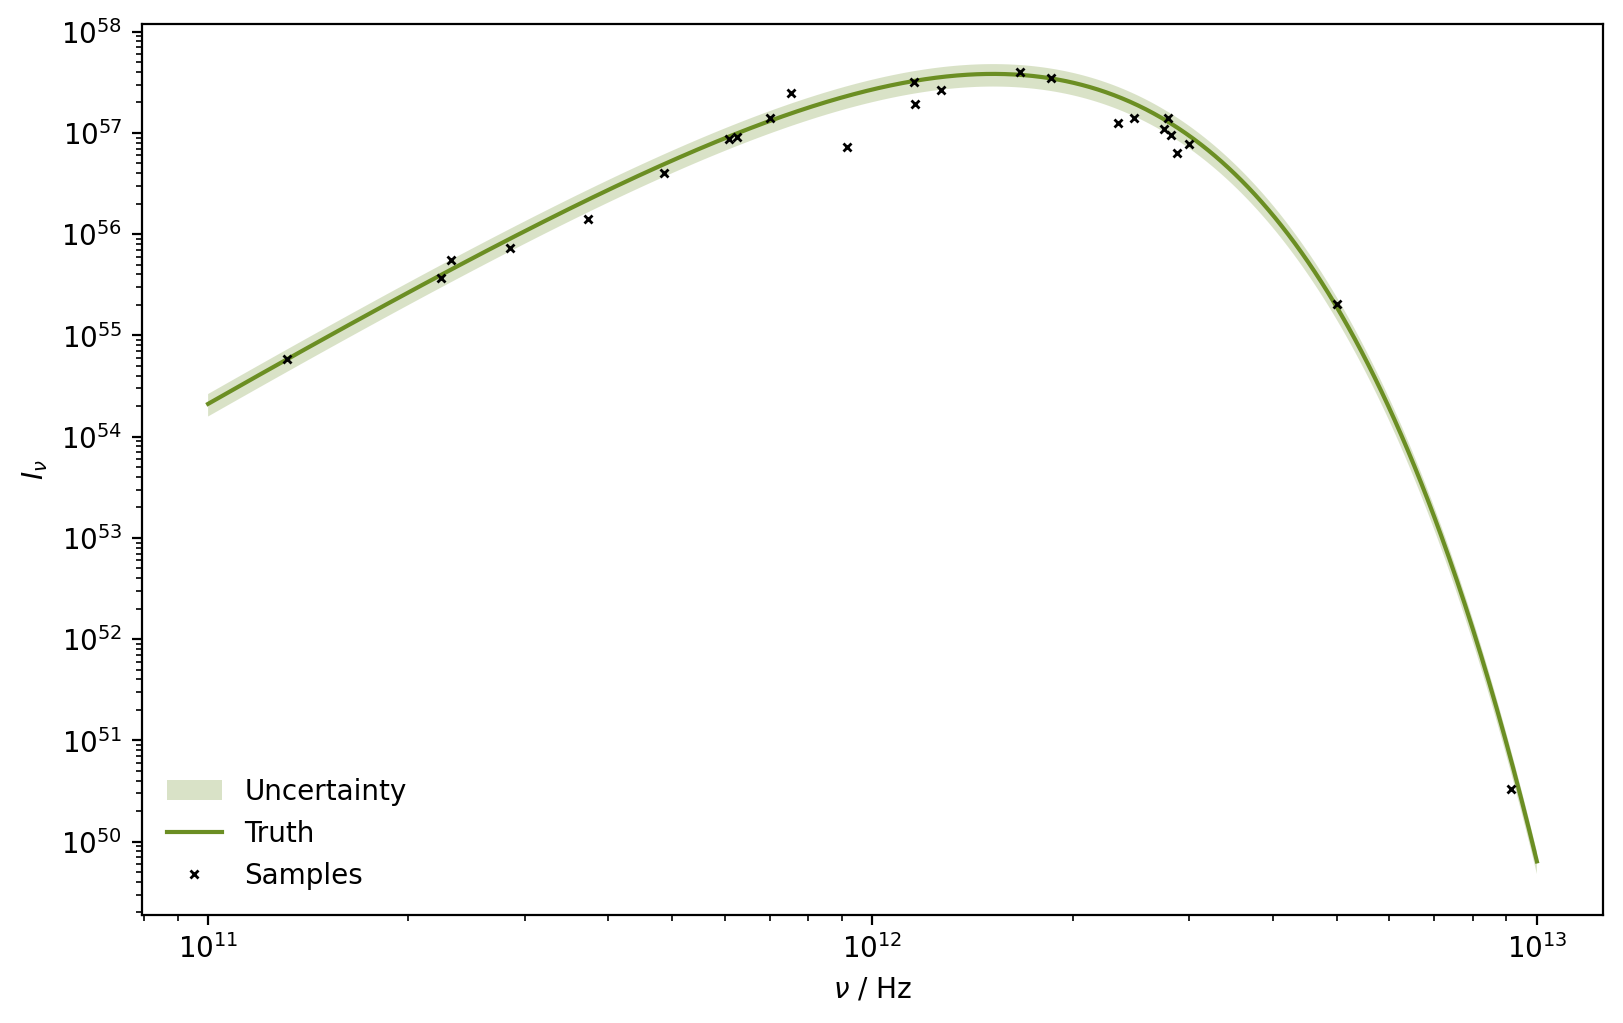

In [5]:
# Plot: Truth and Measurement

x = np.logspace(11, 13, 1000)
y = modBB(x, TT, bb)

plt.fill_between(x, (1 + u) * y, (1 - u) * y, alpha=0.25, label='Uncertainty')
plt.plot(x, y, label='Truth')
plt.plot(ff, II, 'kx', ms=3.21, label='Samples')

plt.xlabel(r'$\nu$ / Hz')
plt.ylabel(r'$I_\nu$')

plt.xscale('log')
plt.yscale('log')

plt.legend(loc='lower left')

plt.show()
plt.close()

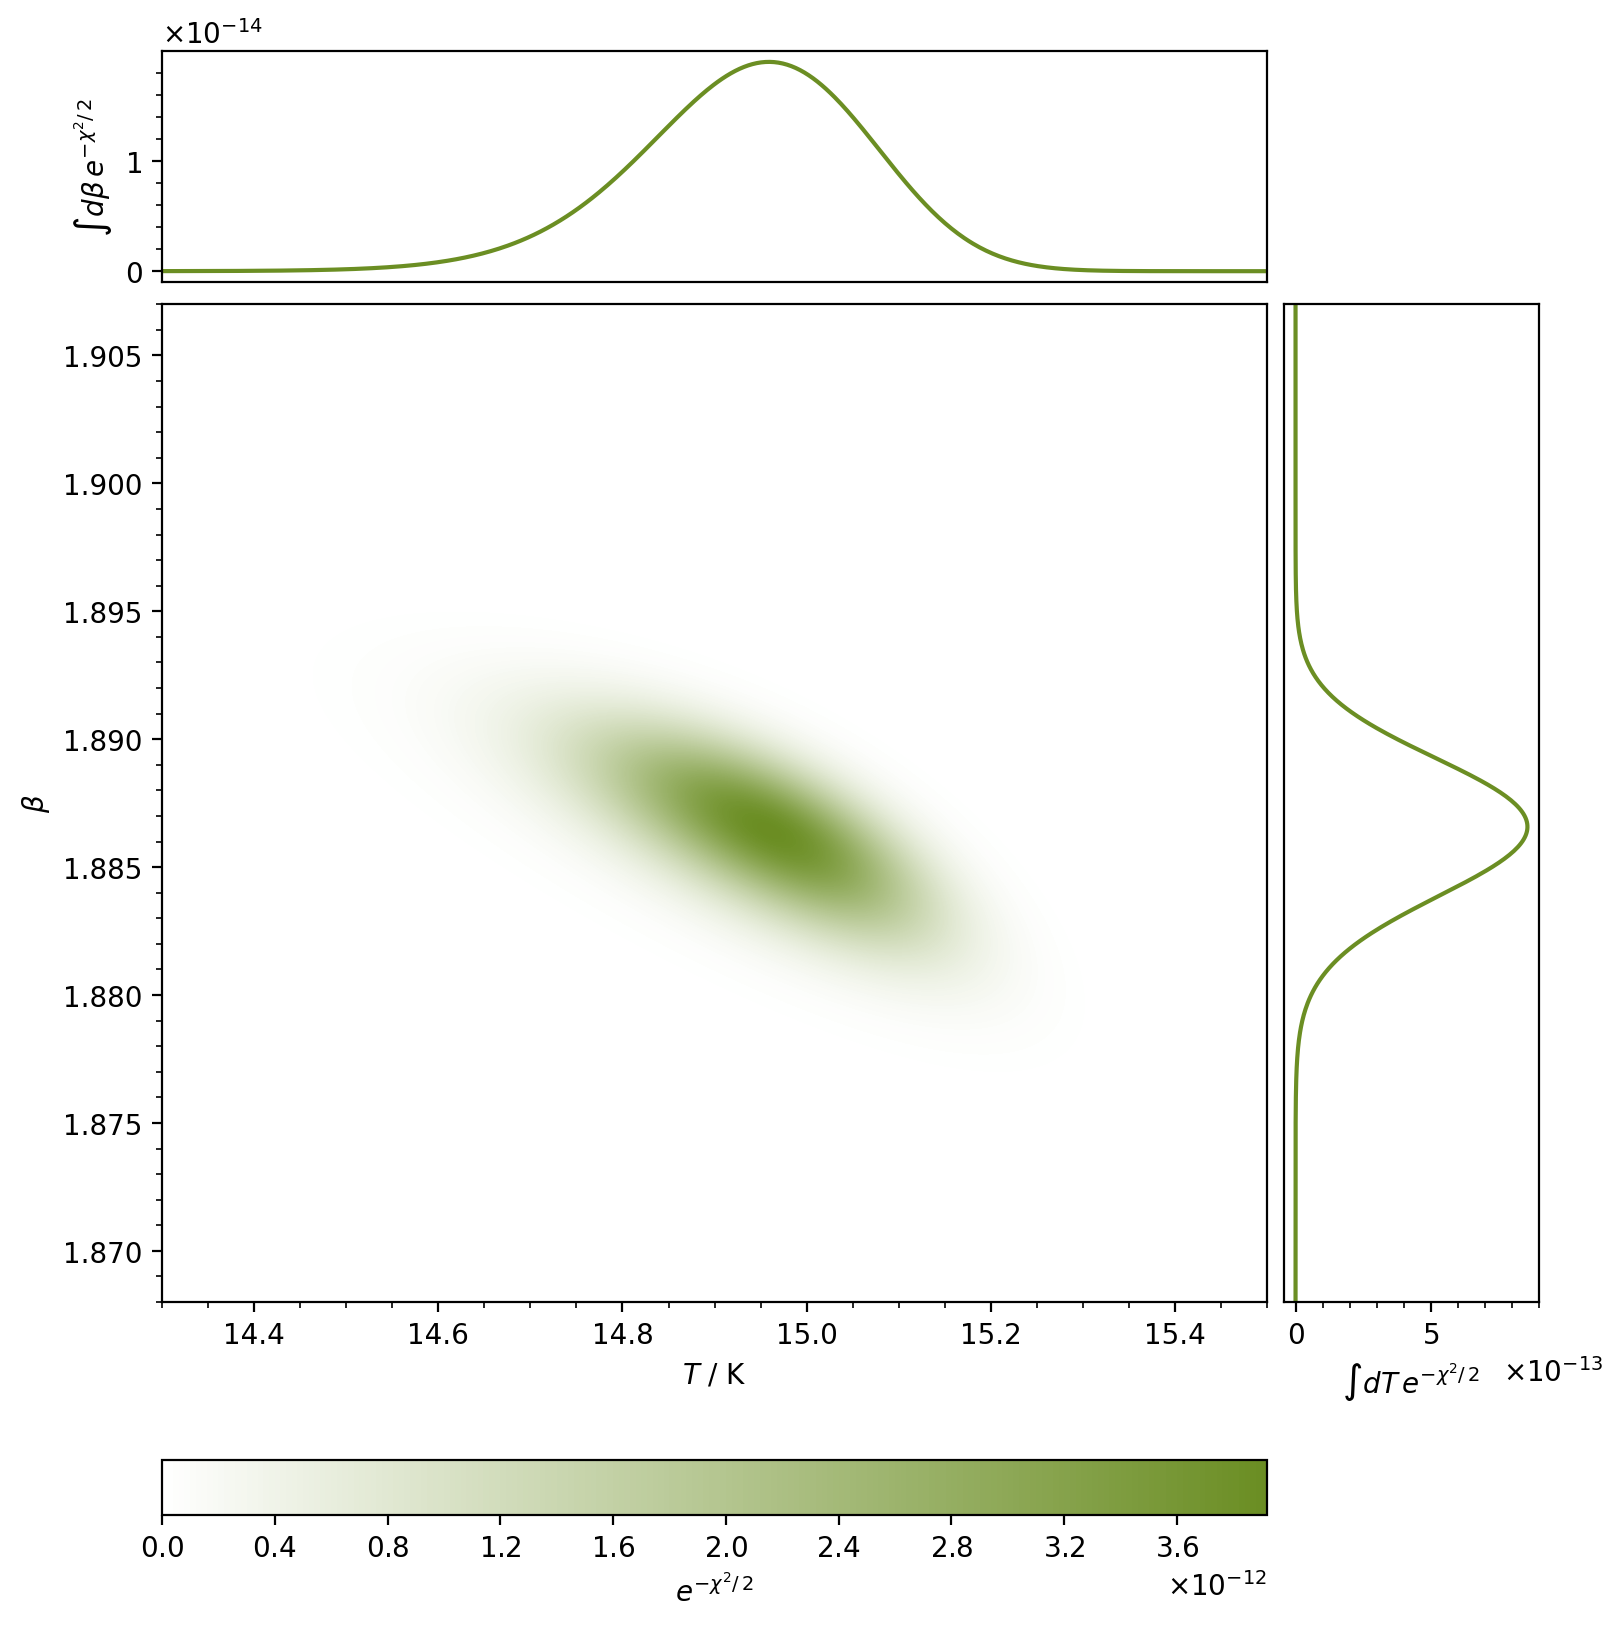

In [6]:
# Plot: Linear Likelihood

s = 512

X = np.linspace(14.3, 15.5, s) / 30.0
Y = np.linspace(1.868, 1.907, s)

X, Y = np.meshgrid(X, Y)

Z = np.zeros(X.shape)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = chiSq(II, ff, uII, X[i, j], Y[i, j])

fig, ax = plt.subplots(2, 2, figsize=(8, 8), height_ratios=[1.5, 6.5], width_ratios=[6.5, 1.5])

cnt = ax[1,0].contourf(30.0 * X, Y, np.exp(-Z/2), 256, cmap=OliveDrab_r)
cnt.set_edgecolor('face')

cb = plt.colorbar(cnt, location='bottom')
cb.set_label(r'$e^{-\chi^2/\,2}$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

xlim = ax[1, 0].set_xlim()
ylim = ax[1, 0].set_ylim()

ax[1,0].set_xlabel(r'$T$ / K')
ax[1,0].set_ylabel(r'$\beta$')

ax[0, 1].axis('off')

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

ax[0,0].plot(30.0 * X[0,:], np.sum(np.exp(-Z / 2) * (Y[1, 0] - Y[0, 0]), axis=0))
ax[0,0].set_xlim(xlim)
ax[0,0].set_ylabel(r'$\int d\beta \, e^{-\chi^2/\,2}$')
ax[0,0].get_xaxis().set_ticks([])
ax[0,0].yaxis.set_major_formatter(formatter)

ax[1,1].plot(np.sum(np.exp(-Z / 2) * 30.0 * (X[0, 1] - X[0, 0]), axis=1), Y[:,0])
ax[1,1].set_ylim(ylim)
ax[1,1].set_xlabel(r'$\int dT \, e^{-\chi^2/\,2}$')
ax[1,1].get_yaxis().set_ticks([])
ax[1,1].xaxis.set_major_formatter(formatter)

exp = ax[1,1].xaxis.get_offset_text()
cur = exp.get_position()
exp.set_position((cur[0] + 0.25, cur[1]))

plt.show()
plt.close()

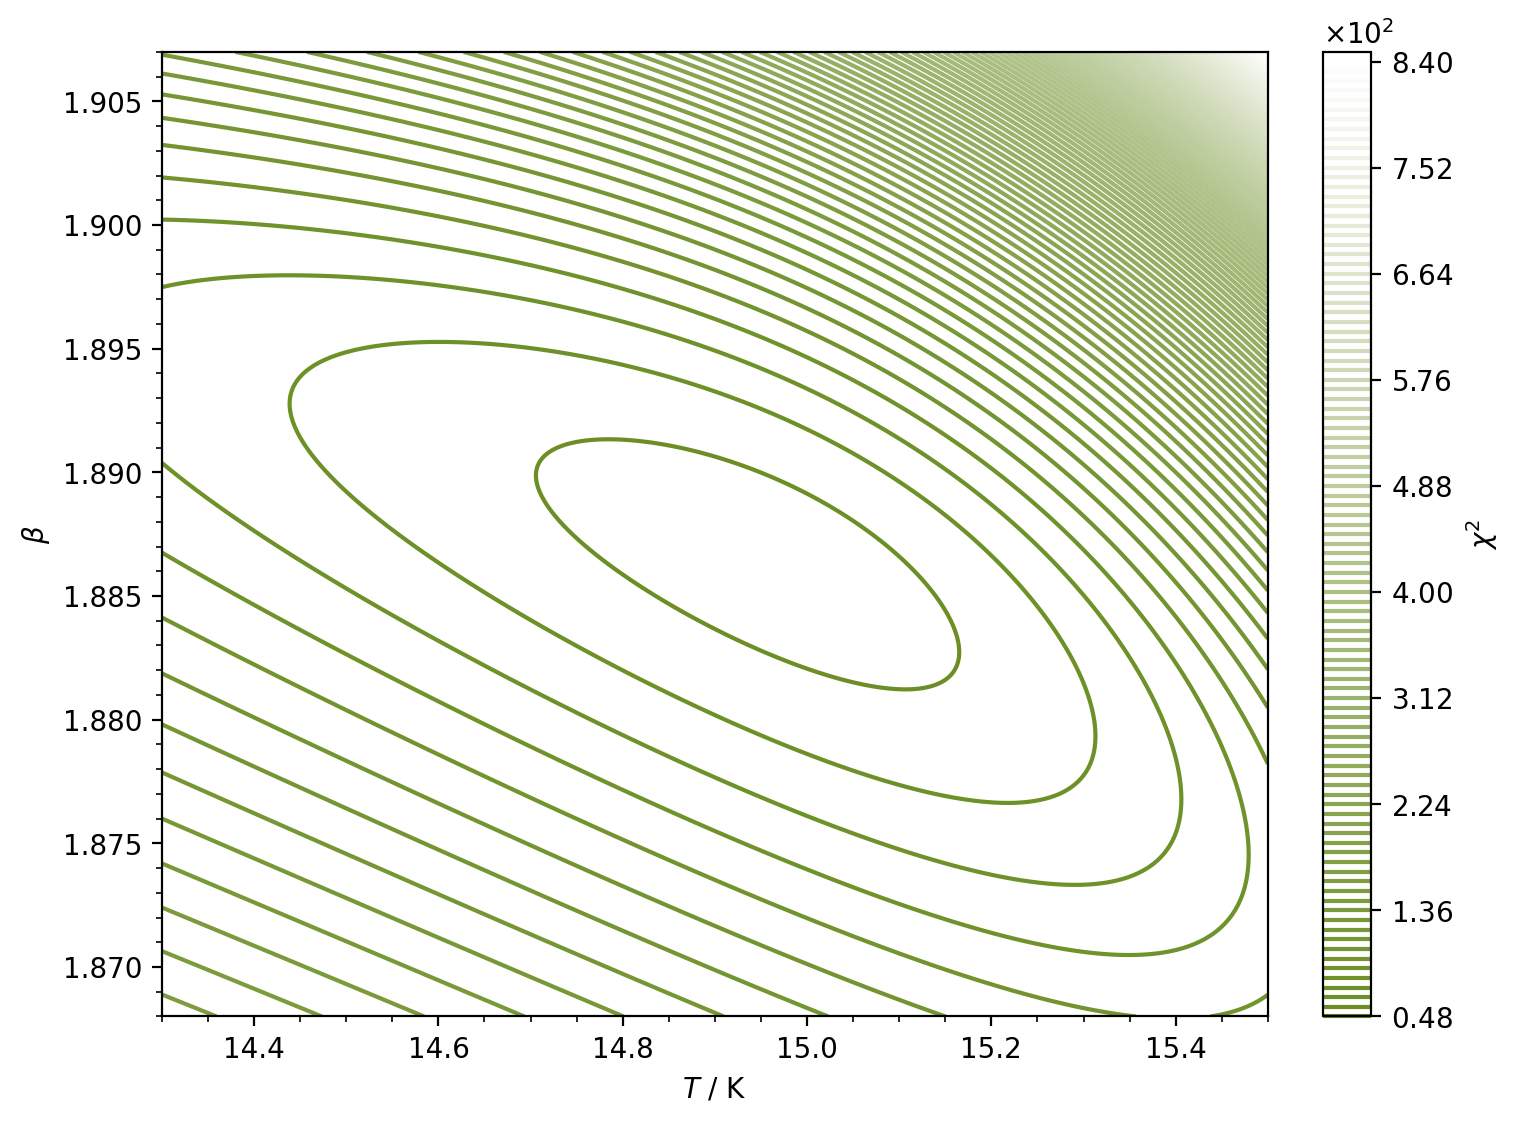

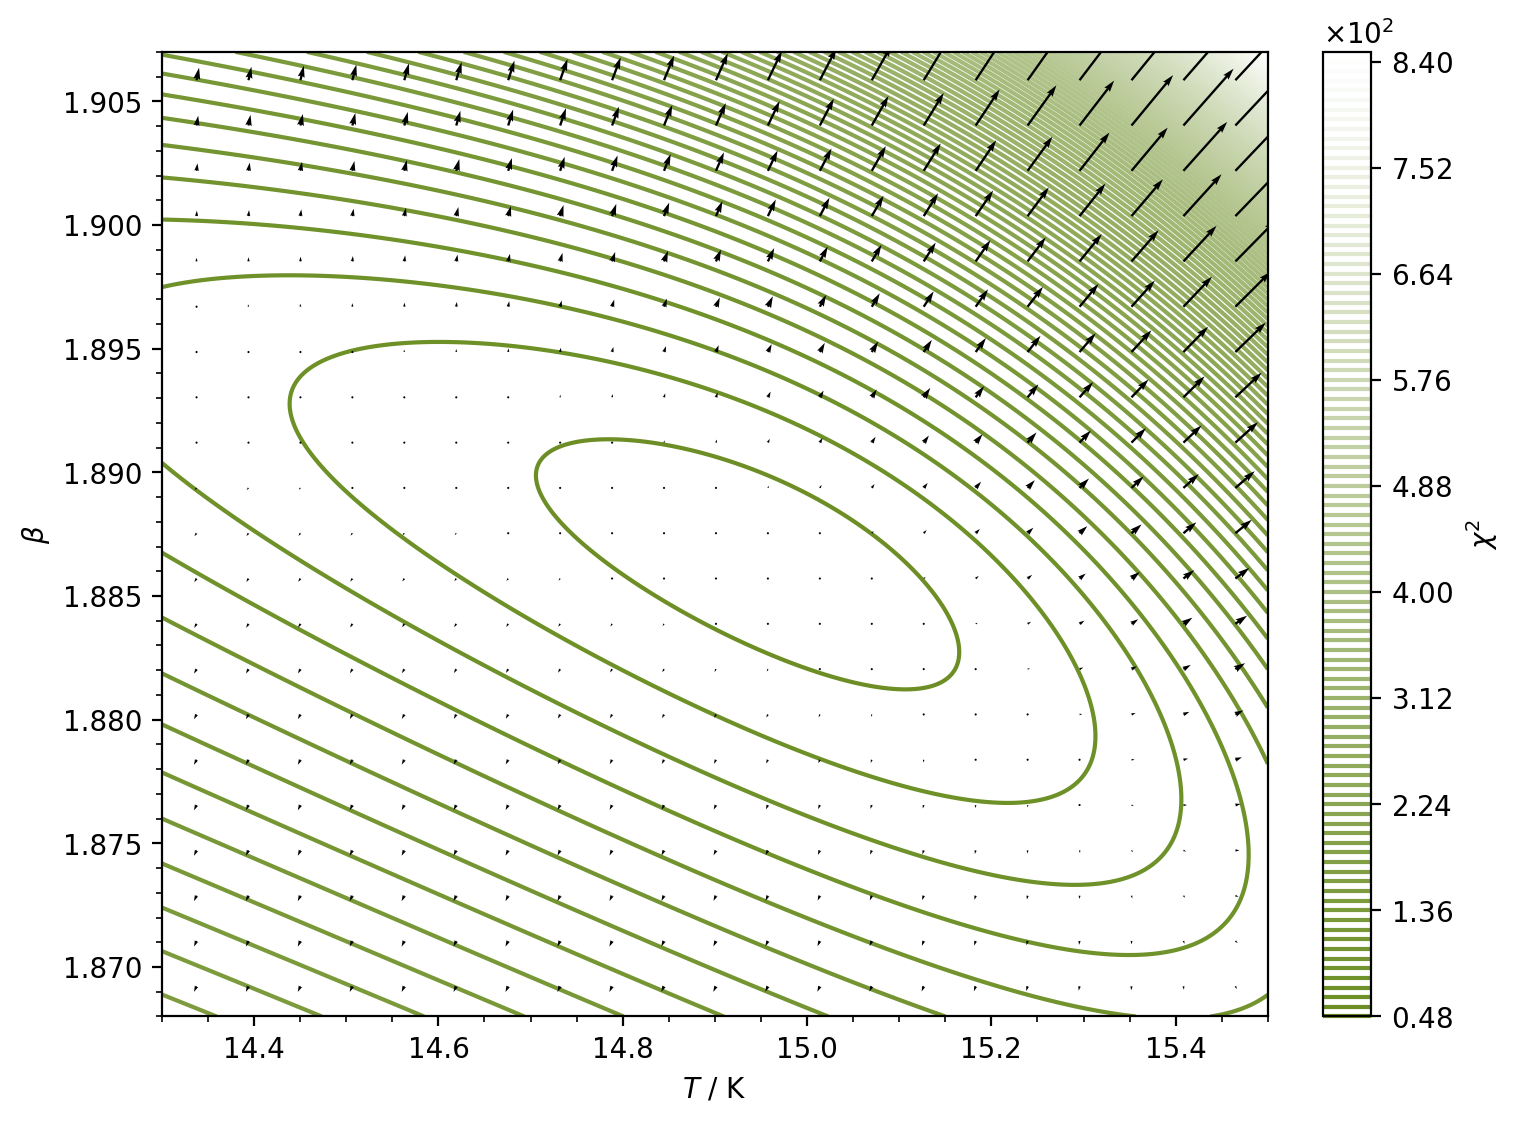

In [7]:
# Plot: Logarithmic Likelihood Quiver

w = 24
v = int((s % w + w) / 2)

gradX = np.zeros(X[v::w, v::w].shape)
gradY = np.zeros(X[v::w, v::w].shape)

for i in range(X[v::w, v::w].shape[0]):
    for j in range(X[v::w, v::w].shape[1]):
        gradX[i, j] = chiSq_TGrad(II, ff, uII, X[v::w, v::w][i, j], Y[v::w, v::w][i, j])
        gradY[i, j] = chiSq_bGrad(II, ff, uII, X[v::w, v::w][i, j], Y[v::w, v::w][i, j])

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contour(30.0 * X, Y, Z, 128, cmap=OliveDrab, zorder=-1)

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$\chi^2$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.show()
plt.close()

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contour(30.0 * X, Y, Z, 128, cmap=OliveDrab, zorder=-1)

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$\chi^2$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

quiv = ax.quiver(30.0 * X[v::w, v::w], Y[v::w, v::w], gradX, gradY, pivot='tail', scale=9e5, width=2.1e-3)

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.show()
plt.close()



initialization:   T = 15.40 K   ß = 1.905
  optimization:   T = 14.99 K   ß = 1.888
    iterations:   k = 100000


initialization:   T = 14.40 K   ß = 1.870
  optimization:   T = 14.99 K   ß = 1.888
    iterations:   k = 100000


initialization:   T = 15.45 K   ß = 1.880
  optimization:   T = 14.99 K   ß = 1.888
    iterations:   k = 100000


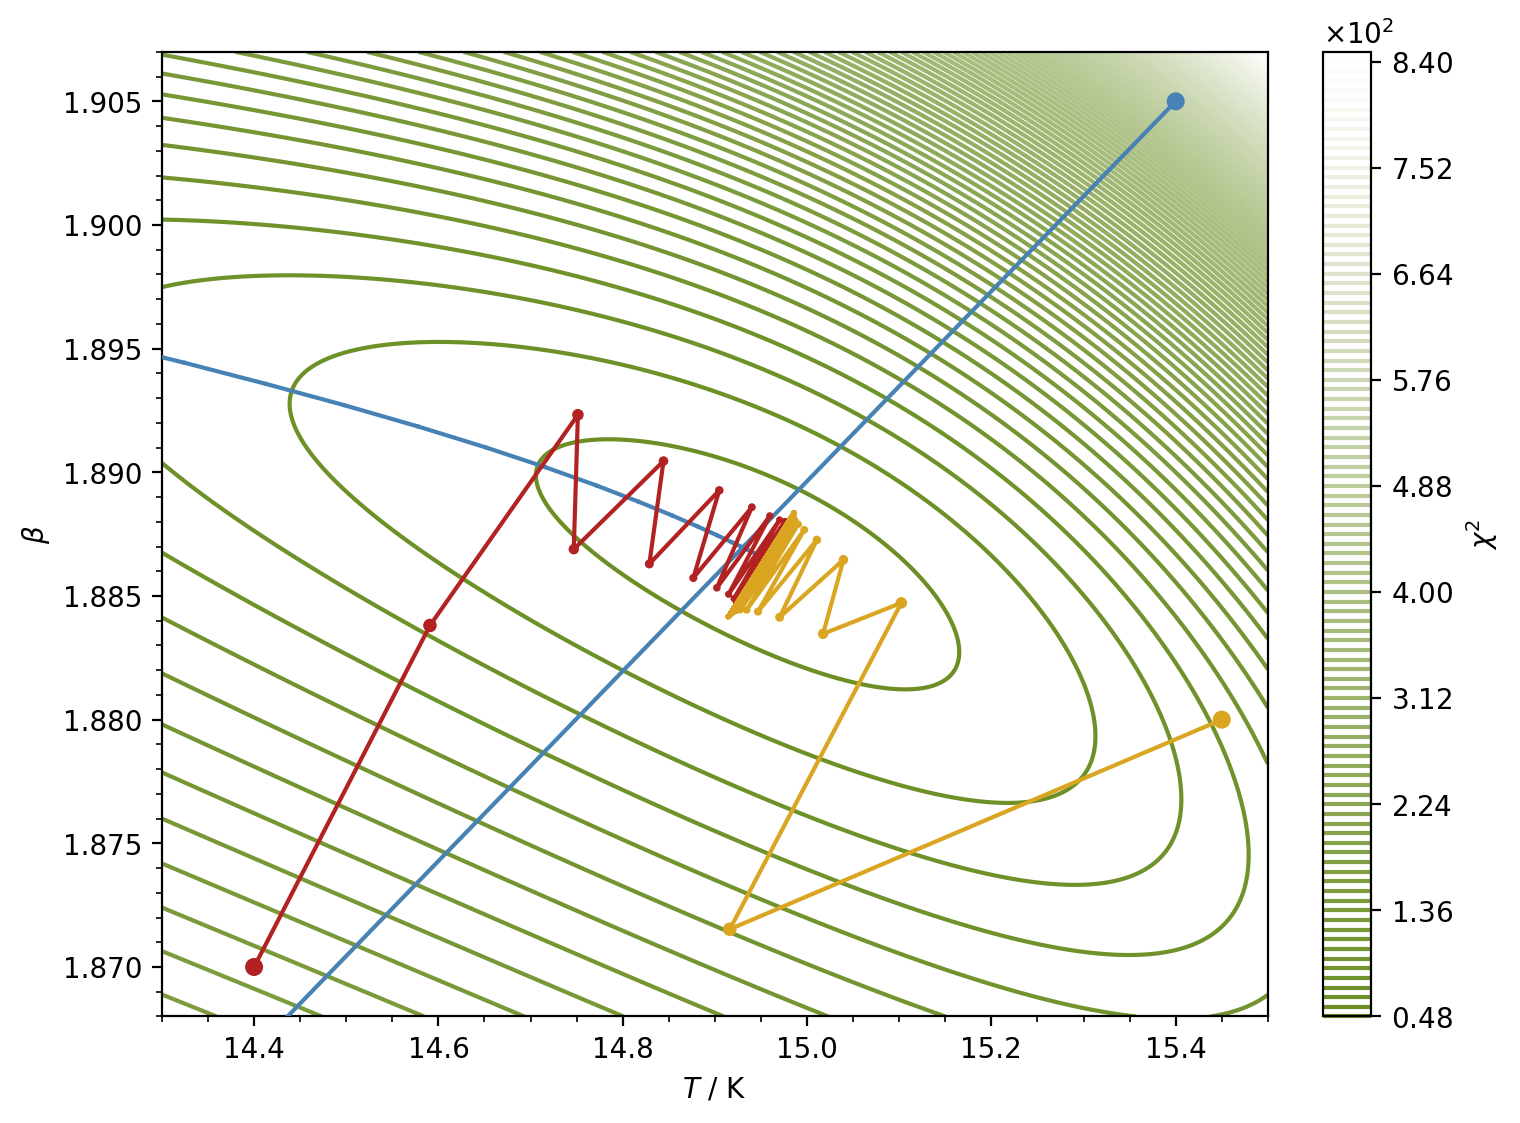



initialization:   T = 15.40 K   ß = 1.905
  optimization:   T = 14.96 K   ß = 1.886
    iterations:   k = 100000


initialization:   T = 14.40 K   ß = 1.870
  optimization:   T = 14.96 K   ß = 1.886
    iterations:   k = 100000


initialization:   T = 15.45 K   ß = 1.880
  optimization:   T = 14.96 K   ß = 1.886
    iterations:   k = 100000


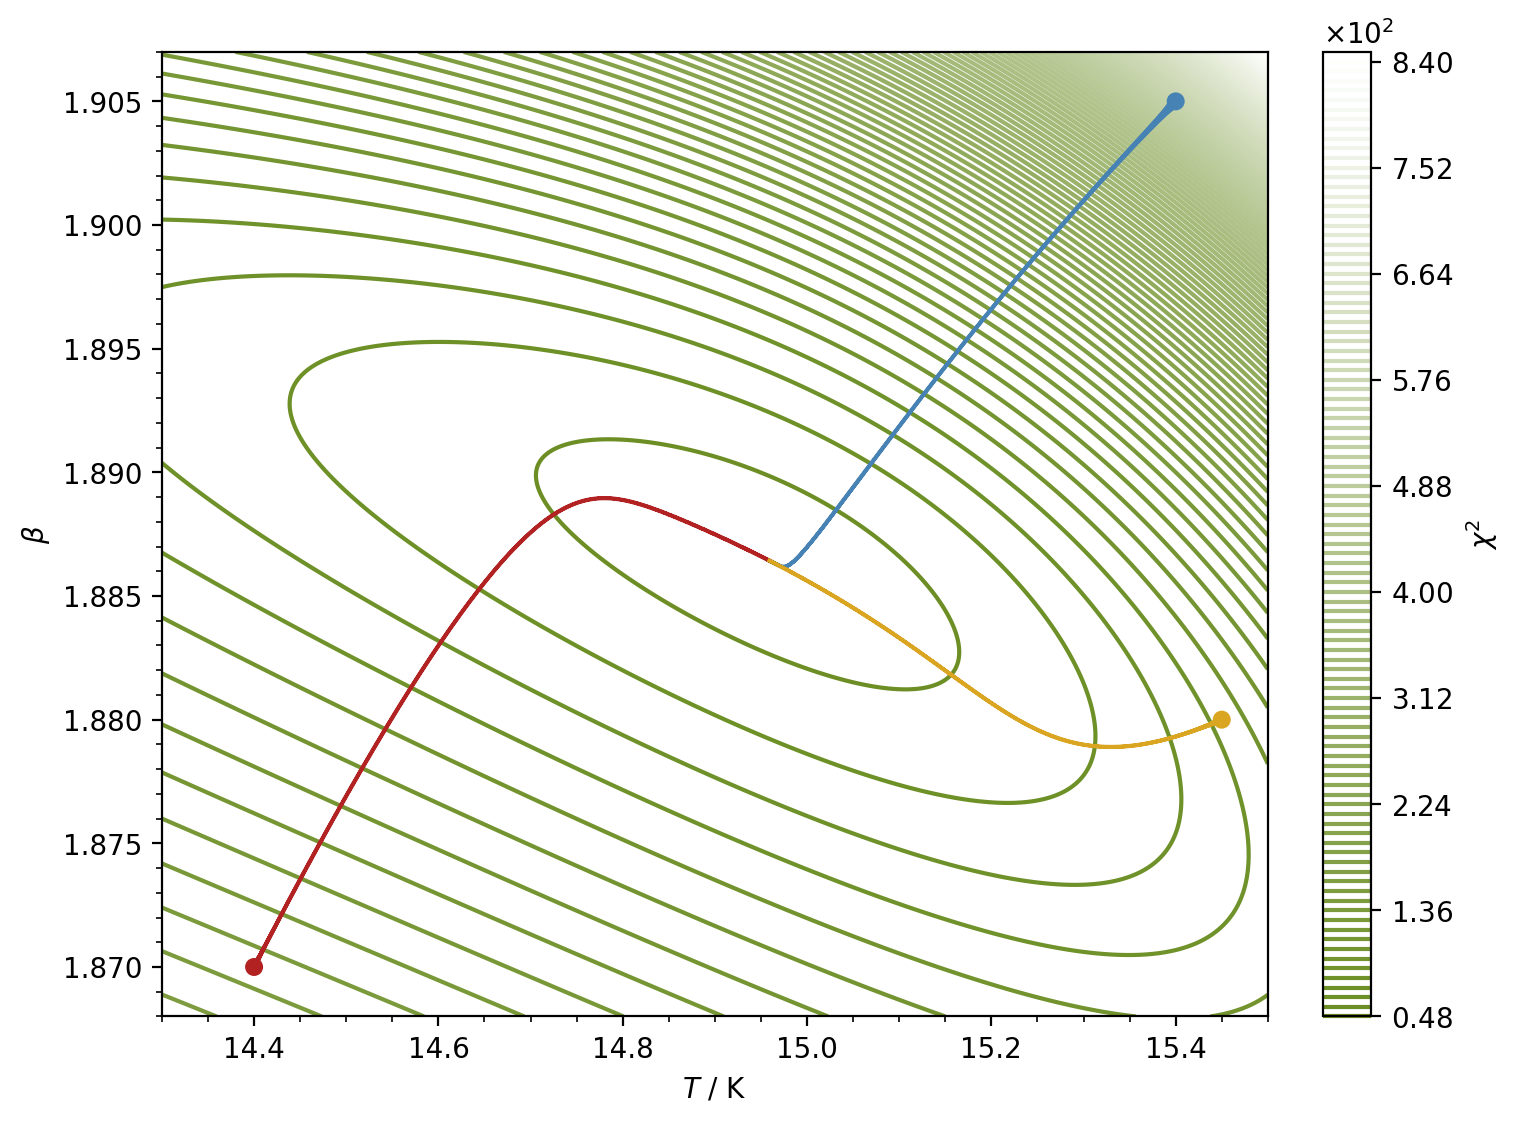

In [24]:
# Plot: Adapted Naive Gradient Descent

steps1, k1 = optGradDesc(II, ff, uII, 15.40, 1.905, alpha = 3e-6)
steps2, k2 = optGradDesc(II, ff, uII, 14.40, 1.870, alpha = 3e-6)
steps3, k3 = optGradDesc(II, ff, uII, 15.45, 1.880, alpha = 3e-6)

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contour(30.0 * X, Y, Z, 128, cmap=OliveDrab, zorder=-1)

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$\chi^2$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.scatter([], [])
ax.plot([], [])

ax.scatter(30.0 * steps1[:, 0], steps1[:, 1], s=(30 / (np.arange(k1 + 1) + 1)), zorder=10)
ax.plot(30.0 * steps1[:, 0], steps1[:, 1], zorder=10)

ax.scatter(30.0 * steps2[:, 0], steps2[:, 1], s=(30 / (np.arange(k2 + 1) + 1)), zorder=20)
ax.plot(30.0 * steps2[:, 0], steps2[:, 1], zorder=20)

ax.scatter(30.0 * steps3[:, 0], steps3[:, 1], s=(30 / (np.arange(k3 + 1) + 1)), zorder=30)
ax.plot(30.0 * steps3[:, 0], steps3[:, 1], zorder=30)

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.xlim(xlim)
plt.ylim(ylim)

plt.show()
plt.close()

steps1, k1 = optGradDesc(II, ff, uII, 15.40, 1.905, alpha = 1e-9)
steps2, k2 = optGradDesc(II, ff, uII, 14.40, 1.870, alpha = 1e-9)
steps3, k3 = optGradDesc(II, ff, uII, 15.45, 1.880, alpha = 1e-9)

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contour(30.0 * X, Y, Z, 128, cmap=OliveDrab, zorder=-1)

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$\chi^2$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.scatter([], [])
ax.plot([], [])

ax.scatter(30.0 * steps1[:, 0], steps1[:, 1], s=(30 / (np.arange(k1 + 1) + 1)), zorder=10)
ax.plot(30.0 * steps1[:, 0], steps1[:, 1], zorder=10)

ax.scatter(30.0 * steps2[:, 0], steps2[:, 1], s=(30 / (np.arange(k2 + 1) + 1)), zorder=20)
ax.plot(30.0 * steps2[:, 0], steps2[:, 1], zorder=20)

ax.scatter(30.0 * steps3[:, 0], steps3[:, 1], s=(30 / (np.arange(k3 + 1) + 1)), zorder=30)
ax.plot(30.0 * steps3[:, 0], steps3[:, 1], zorder=30)

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.xlim(xlim)
plt.ylim(ylim)

plt.show()
plt.close()



initialization:   T = 15.40 K   ß = 1.905
  optimization:   T = 14.96 K   ß = 1.886
    iterations:   k = 429


initialization:   T = 14.40 K   ß = 1.870
  optimization:   T = 14.96 K   ß = 1.886
    iterations:   k = 436


initialization:   T = 15.45 K   ß = 1.880
  optimization:   T = 14.96 K   ß = 1.886
    iterations:   k = 432


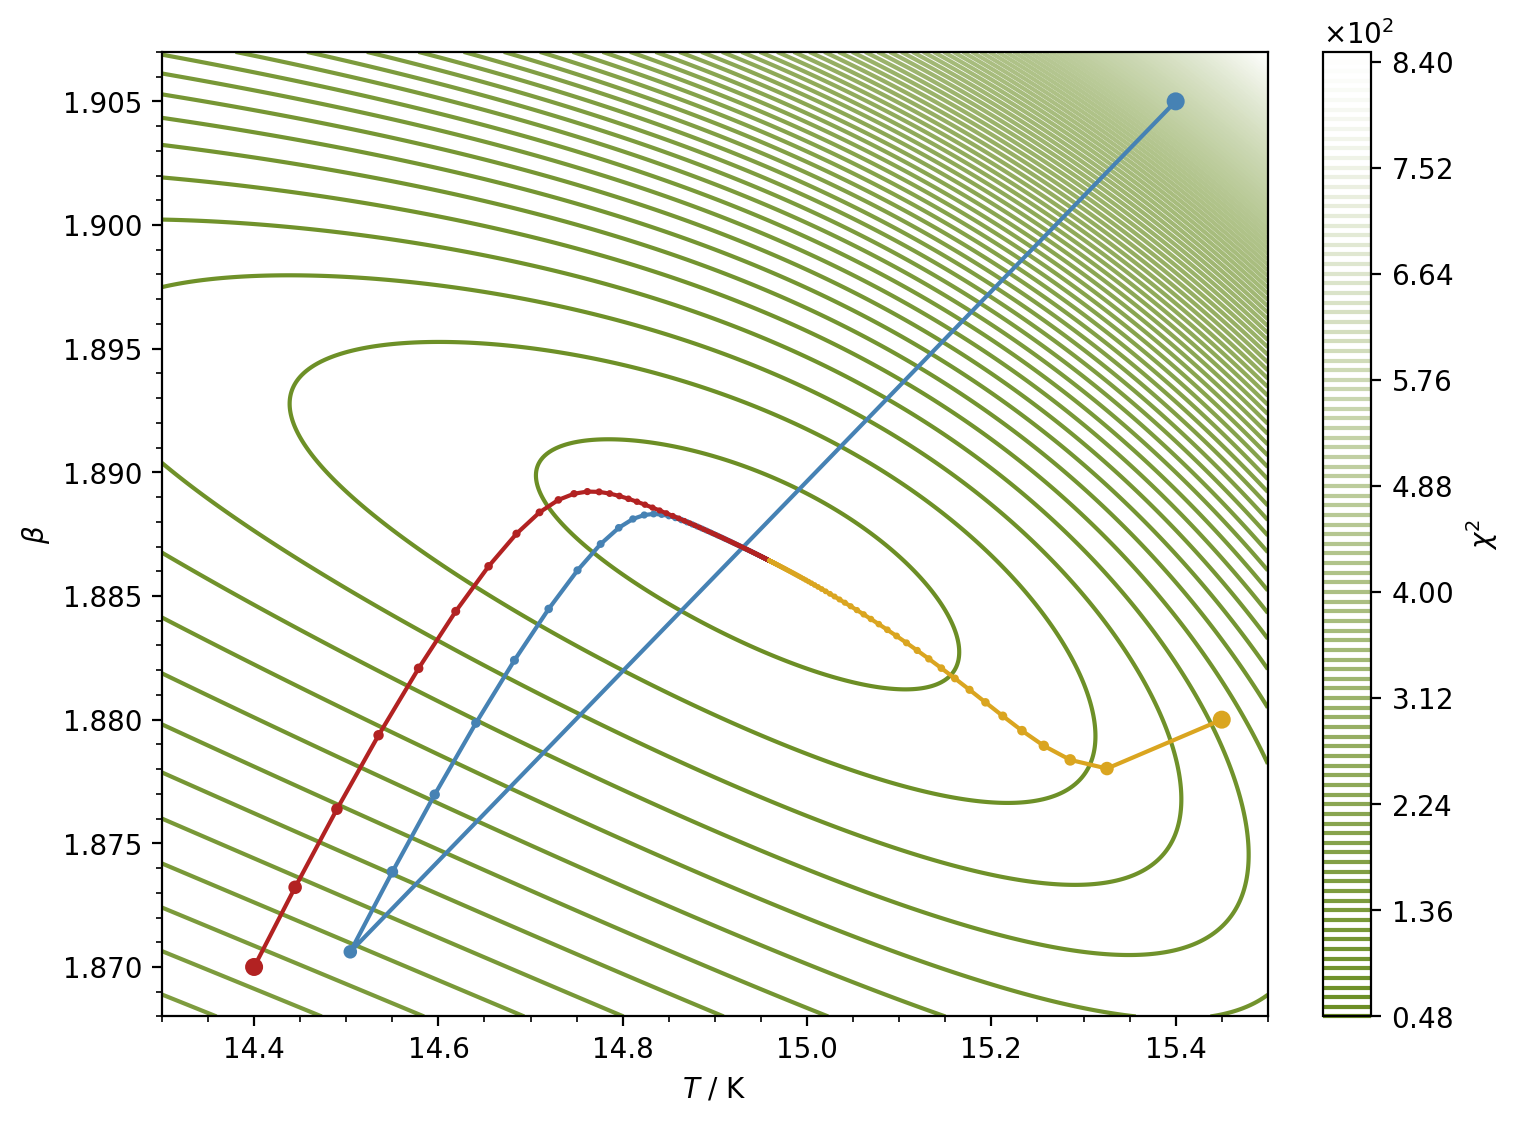

In [33]:
# Plot: Default Naive Gradient Descent

steps1, k1 = optGradDesc(II, ff, uII, 15.40, 1.905)
steps2, k2 = optGradDesc(II, ff, uII, 14.40, 1.870)
steps3, k3 = optGradDesc(II, ff, uII, 15.45, 1.880)

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contour(30.0 * X, Y, Z, 128, cmap=OliveDrab, zorder=-1)

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$\chi^2$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.scatter([], [])
ax.plot([], [])

ax.scatter(30.0 * steps1[:, 0], steps1[:, 1], s=(30 / (np.arange(k1 + 1) + 1)), zorder=10)
ax.plot(30.0 * steps1[:, 0], steps1[:, 1], zorder=10)

ax.scatter(30.0 * steps2[:, 0], steps2[:, 1], s=(30 / (np.arange(k2 + 1) + 1)), zorder=20)
ax.plot(30.0 * steps2[:, 0], steps2[:, 1], zorder=20)

ax.scatter(30.0 * steps3[:, 0], steps3[:, 1], s=(30 / (np.arange(k3 + 1) + 1)), zorder=30)
ax.plot(30.0 * steps3[:, 0], steps3[:, 1], zorder=30)

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.xlim(xlim)
plt.ylim(ylim)

plt.show()
plt.close()



initialization:   T = 15.40 K   ß = 1.905
  optimization:   T = 14.96 K   ß = 1.886
    iterations:   k = 37


initialization:   T = 14.40 K   ß = 1.870
  optimization:   T = 14.96 K   ß = 1.886
    iterations:   k = 40


initialization:   T = 15.45 K   ß = 1.880
  optimization:   T = 14.96 K   ß = 1.886
    iterations:   k = 39


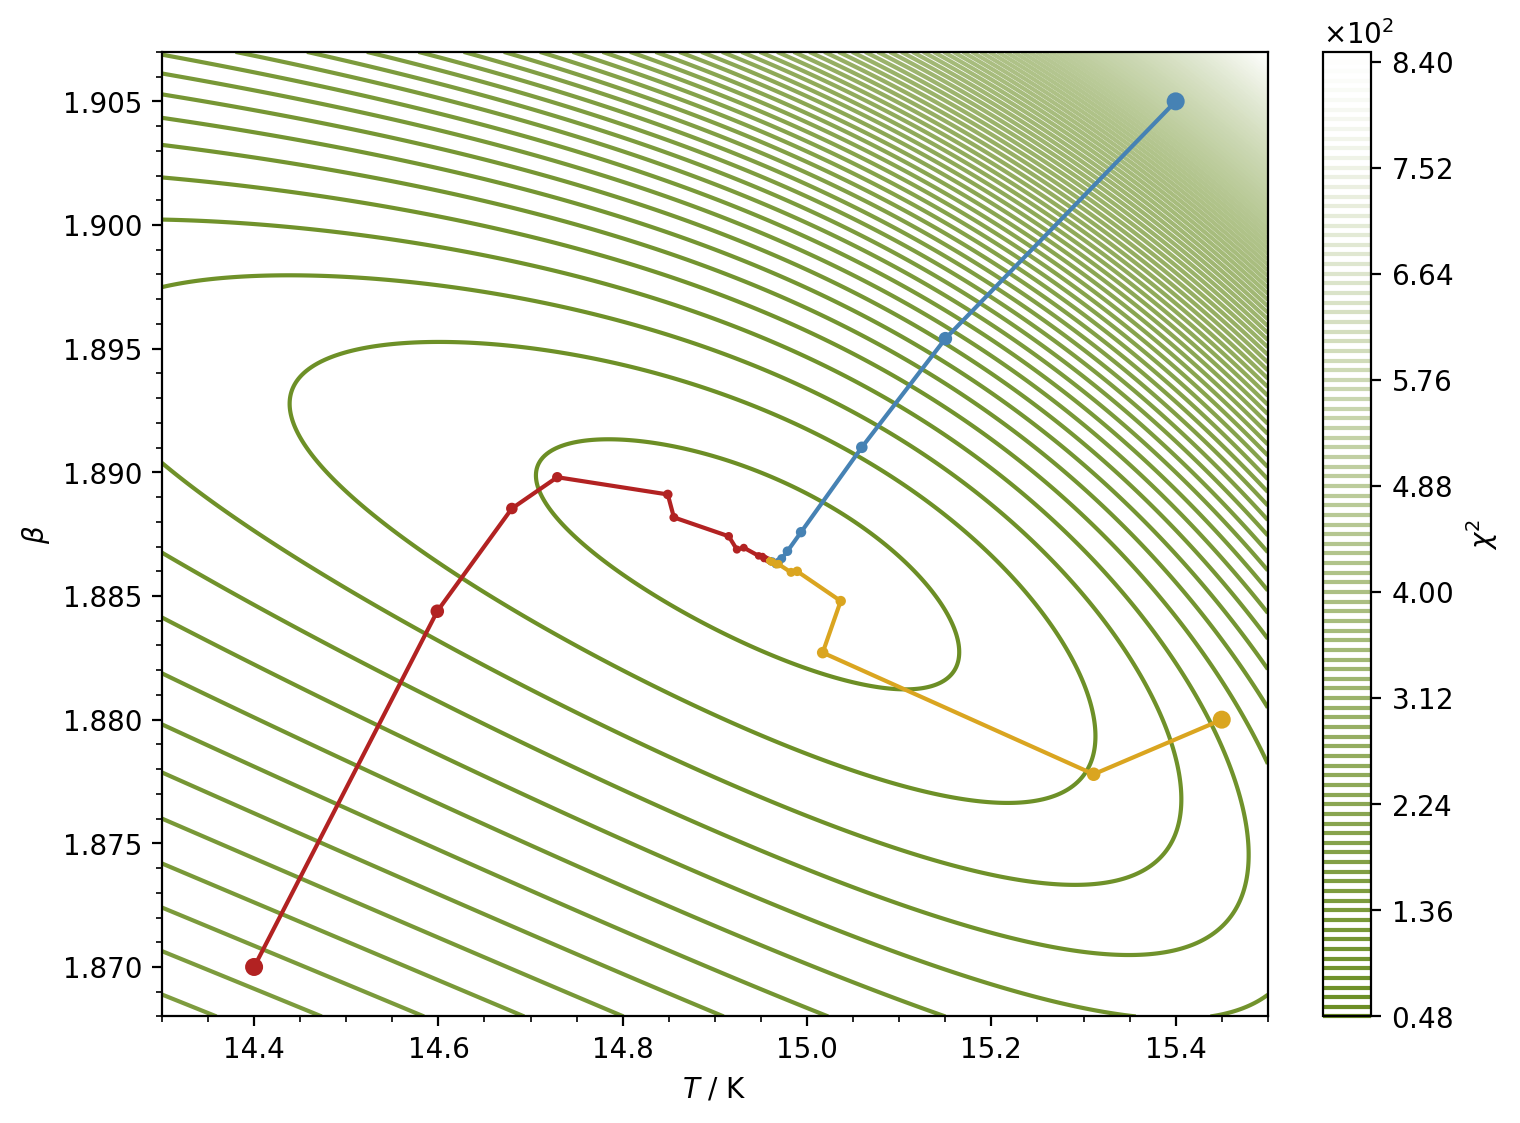

In [10]:
# Plot: Backtracking Line Search

steps4, k4, alpha4 = optGradDescLinSearch(II, ff, uII, 15.40, 1.905)
steps5, k5, alpha5 = optGradDescLinSearch(II, ff, uII, 14.40, 1.870)
steps6, k6, alpha6 = optGradDescLinSearch(II, ff, uII, 15.45, 1.880)

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contour(30.0 * X, Y, Z, 128, cmap=OliveDrab, zorder=-1)

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$\chi^2$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.scatter([], [])
ax.plot([], [])

ax.scatter(30.0 * steps4[:, 0], steps4[:, 1], s=(30 / (np.arange(k4 + 1) + 1)), zorder=10)
ax.plot(30.0 * steps4[:, 0], steps4[:, 1], zorder=10)

ax.scatter(30.0 * steps5[:, 0], steps5[:, 1], s=(30 / (np.arange(k5 + 1) + 1)), zorder=20)
ax.plot(30.0 * steps5[:, 0], steps5[:, 1], zorder=20)

ax.scatter(30.0 * steps6[:, 0], steps6[:, 1], s=(30 / (np.arange(k6 + 1) + 1)), zorder=30)
ax.plot(30.0 * steps6[:, 0], steps6[:, 1], zorder=30)

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.show()
plt.close()

par = (steps4[-1, :] + steps5[-1, :] + steps6[-1, :]) / 3
minChiSq = chiSq(II, ff, uII, *par)

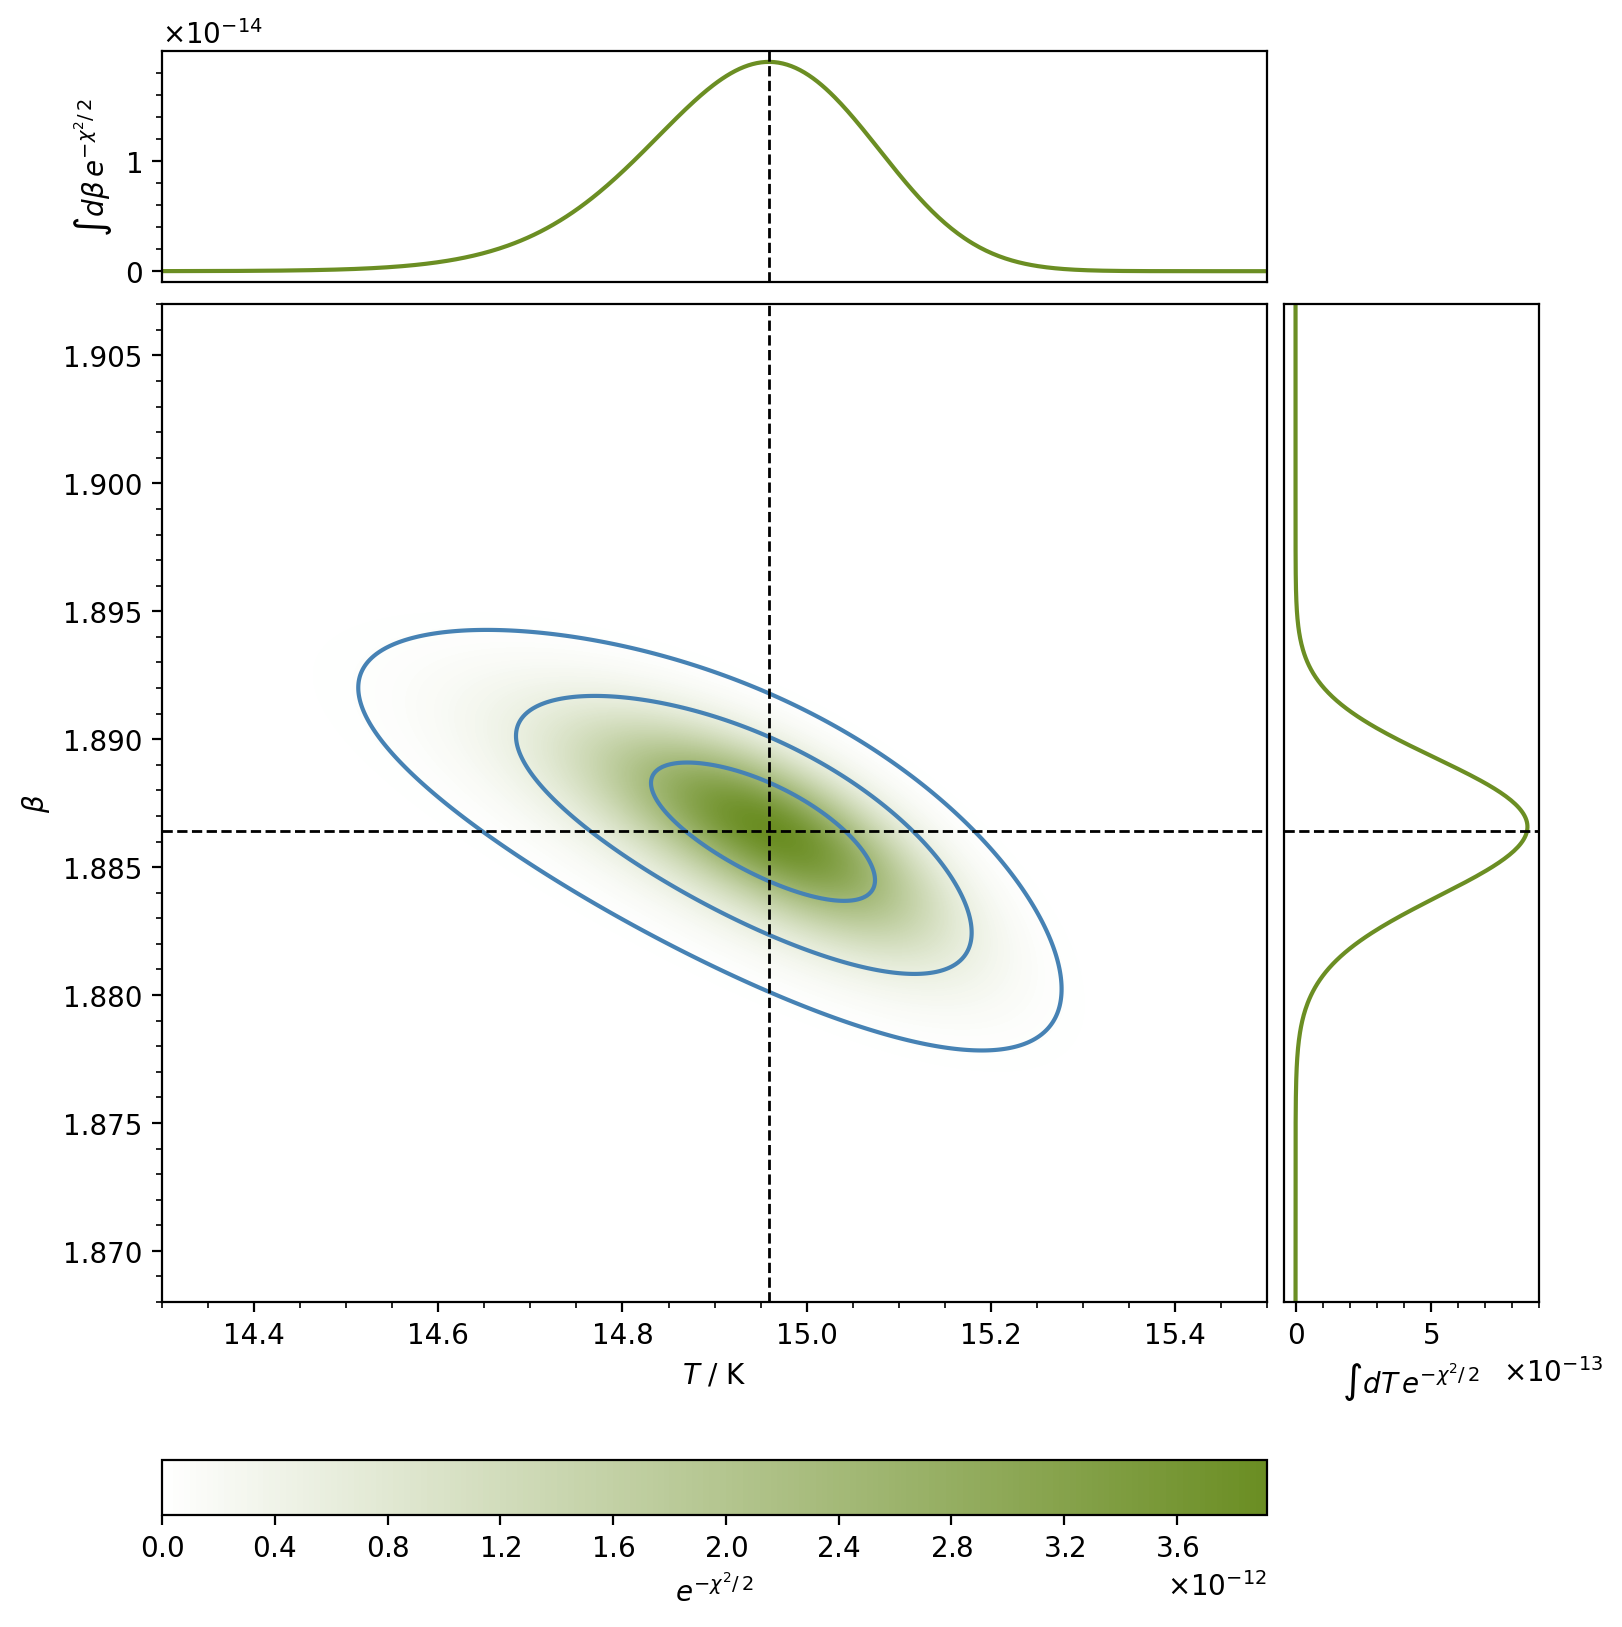

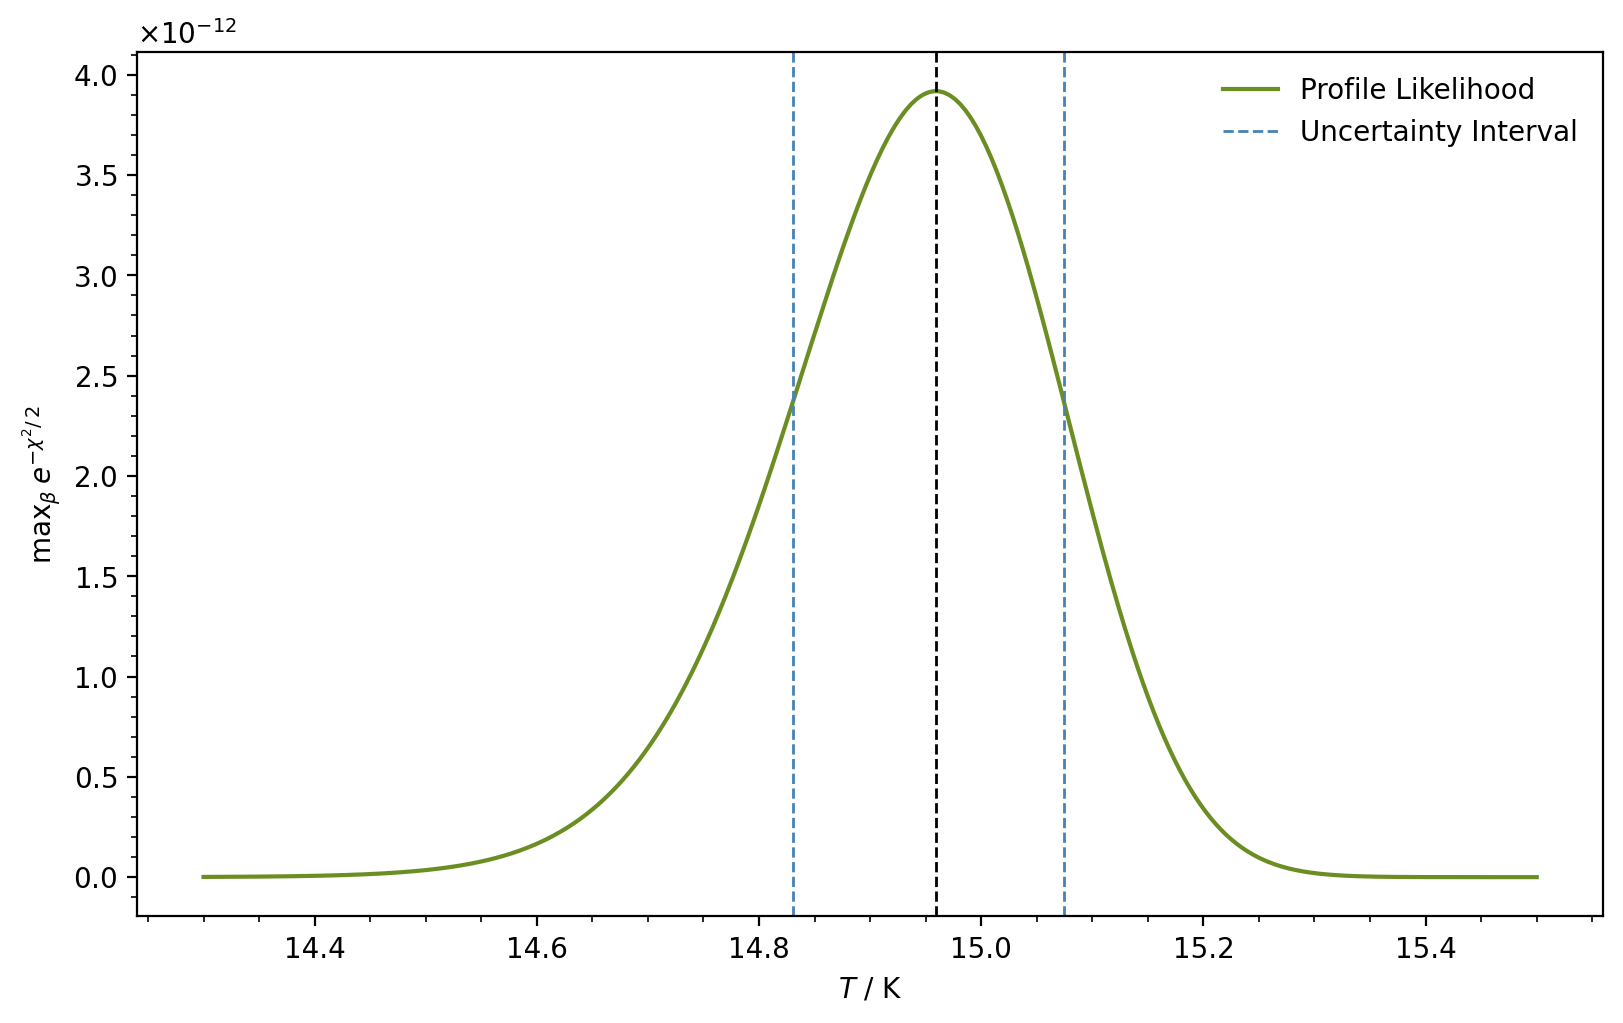

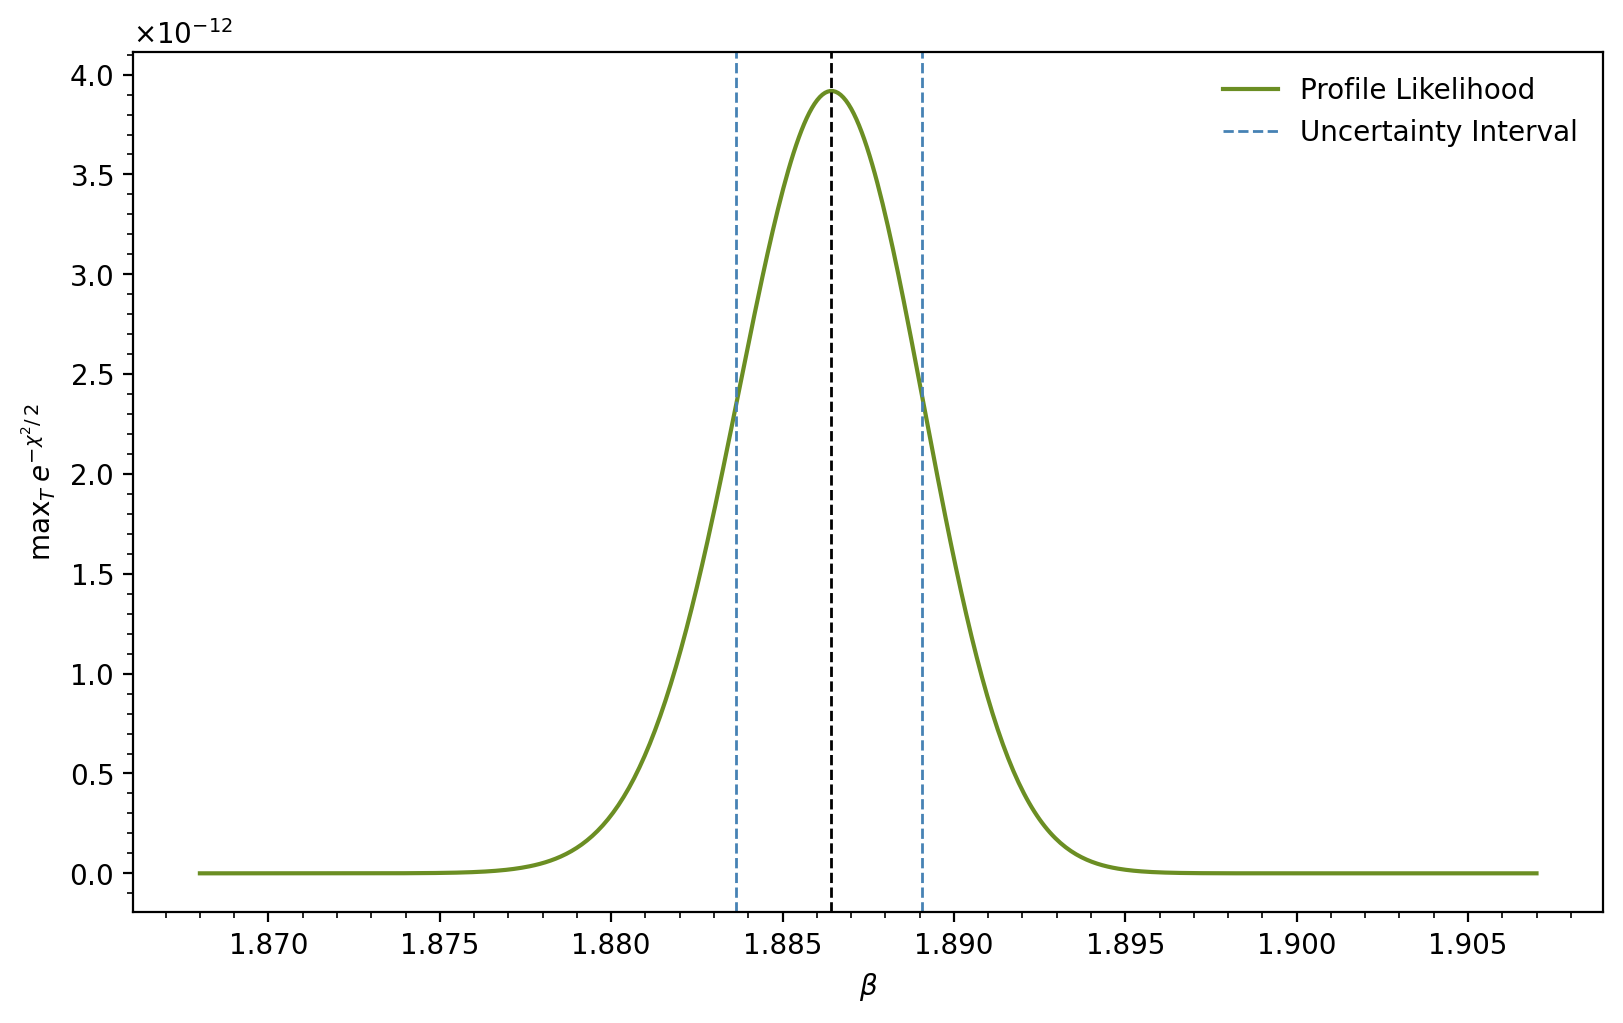

T = 14.96(+0.12)(-0.13) K
ß = 1.8864(+0.0026)(-0.0028)


In [11]:
# Plot: Sigma Contours and Profiled Distributions

fig, ax = plt.subplots(2, 2, figsize=(8, 8), height_ratios=[1.5, 6.5], width_ratios=[6.5, 1.5])

cnt = ax[1,0].contourf(30.0 * X, Y, np.exp(-Z/2), 256, cmap=OliveDrab_r)
cnt.set_edgecolor('face')

cb = plt.colorbar(cnt, location='bottom')
cb.set_label(r'$e^{-\chi^2/\,2}$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax[1,0].contour(30 * X, Y, Z, levels=[minChiSq + 1.0, minChiSq + 4.0, minChiSq + 9.0], colors='steelblue')

ax[1,0].axvline(30.0 * par[0], c='k', ls='--', lw=1.0)
ax[1,0].axhline(par[1], c='k', ls='--', lw=1.0)

xlim = ax[1, 0].set_xlim()
ylim = ax[1, 0].set_ylim()

ax[1,0].set_xlabel(r'$T$ / K')
ax[1,0].set_ylabel(r'$\beta$')

ax[0, 1].axis('off')

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

ax[0,0].plot(30.0 * X[0,:], np.sum(np.exp(-Z / 2) * (Y[1, 0] - Y[0, 0]), axis=0))
ax[0,0].set_xlim(xlim)
ax[0,0].set_ylabel(r'$\int d\beta \, e^{-\chi^2/\,2}$')
ax[0,0].get_xaxis().set_ticks([])
ax[0,0].yaxis.set_major_formatter(formatter)
ax[0,0].axvline(30.0 * par[0], c='k', ls='--', lw=1.0)

ax[1,1].plot(np.sum(np.exp(-Z / 2) * 30.0 * (X[0, 1] - X[0, 0]), axis=1), Y[:,0])
ax[1,1].set_ylim(ylim)
ax[1,1].set_xlabel(r'$\int dT \, e^{-\chi^2/\,2}$')
ax[1,1].get_yaxis().set_ticks([])
ax[1,1].xaxis.set_major_formatter(formatter)
ax[1,1].axhline(par[1], c='k', ls='--', lw=1.0)

exp = ax[1,1].xaxis.get_offset_text()
cur = exp.get_position()
exp.set_position((cur[0] + 0.25, cur[1]))

plt.show()
plt.close()

profX = np.min(Z, axis=0)
profY = np.min(Z, axis=1)

minArgProfX = np.argmin(profX)
minArgProfY = np.argmin(profY)

leftArgX = np.argmin(np.abs(profX[:minArgProfX] - minChiSq - 1.0))
rightArgX = np.argmin(np.abs(profX[minArgProfX:] - minChiSq - 1.0)) + minArgProfX

leftArgY = np.argmin(np.abs(profY[:minArgProfY] - minChiSq - 1.0))
rightArgY = np.argmin(np.abs(profY[minArgProfY:] - minChiSq - 1.0)) + minArgProfY

leftSigX = 30.0 * X[0, leftArgX]
rightSigX = 30.0 * X[0, rightArgX]

leftSigY = Y[leftArgY, 0]
rightSigY = Y[rightArgY, 0]

plt.plot(30.0 * X[0, :], np.exp(-profX / 2), label='Profile Likelihood')
plt.axvline(30.0 * par[0], c='k', ls='--', lw=1.0)

plt.gca().yaxis.set_major_formatter(formatter)

plt.xlabel(r'$T$ / K')
plt.ylabel(r'max$_\beta\:e^{-\chi^2/\,2}$')
plt.axvline(leftSigX, c='steelblue', ls='--', lw=1.0)
plt.axvline(rightSigX, c='steelblue', ls='--', lw=1.0, label='Uncertainty Interval')

plt.legend(loc='upper right')

plt.show()
plt.close()

plt.plot(Y[:, 0], np.exp(-profY / 2), label='Profile Likelihood')
plt.axvline(par[1], c='k', ls='--', lw=1.0)
plt.axvline(leftSigY, c='steelblue', ls='--', lw=1.0)
plt.axvline(rightSigY, c='steelblue', ls='--', lw=1.0, label='Uncertainty Interval')

plt.gca().yaxis.set_major_formatter(formatter)

plt.xlabel(r'$\beta$')
plt.ylabel(r'max$_T\:e^{-\chi^2/\,2}$')

plt.legend(loc='upper right')

plt.show()
plt.close()

print(f'T = {30.0 * par[0]:.2f}(+{(rightSigX - 30.0 * par[0]):.2f})(-{(30.0 * par[0] - leftSigX):.2f}) K')
print(f'ß = {par[1]:.4f}(+{(rightSigY - par[1]):.4f})(-{(par[1] - leftSigY):.4f})')

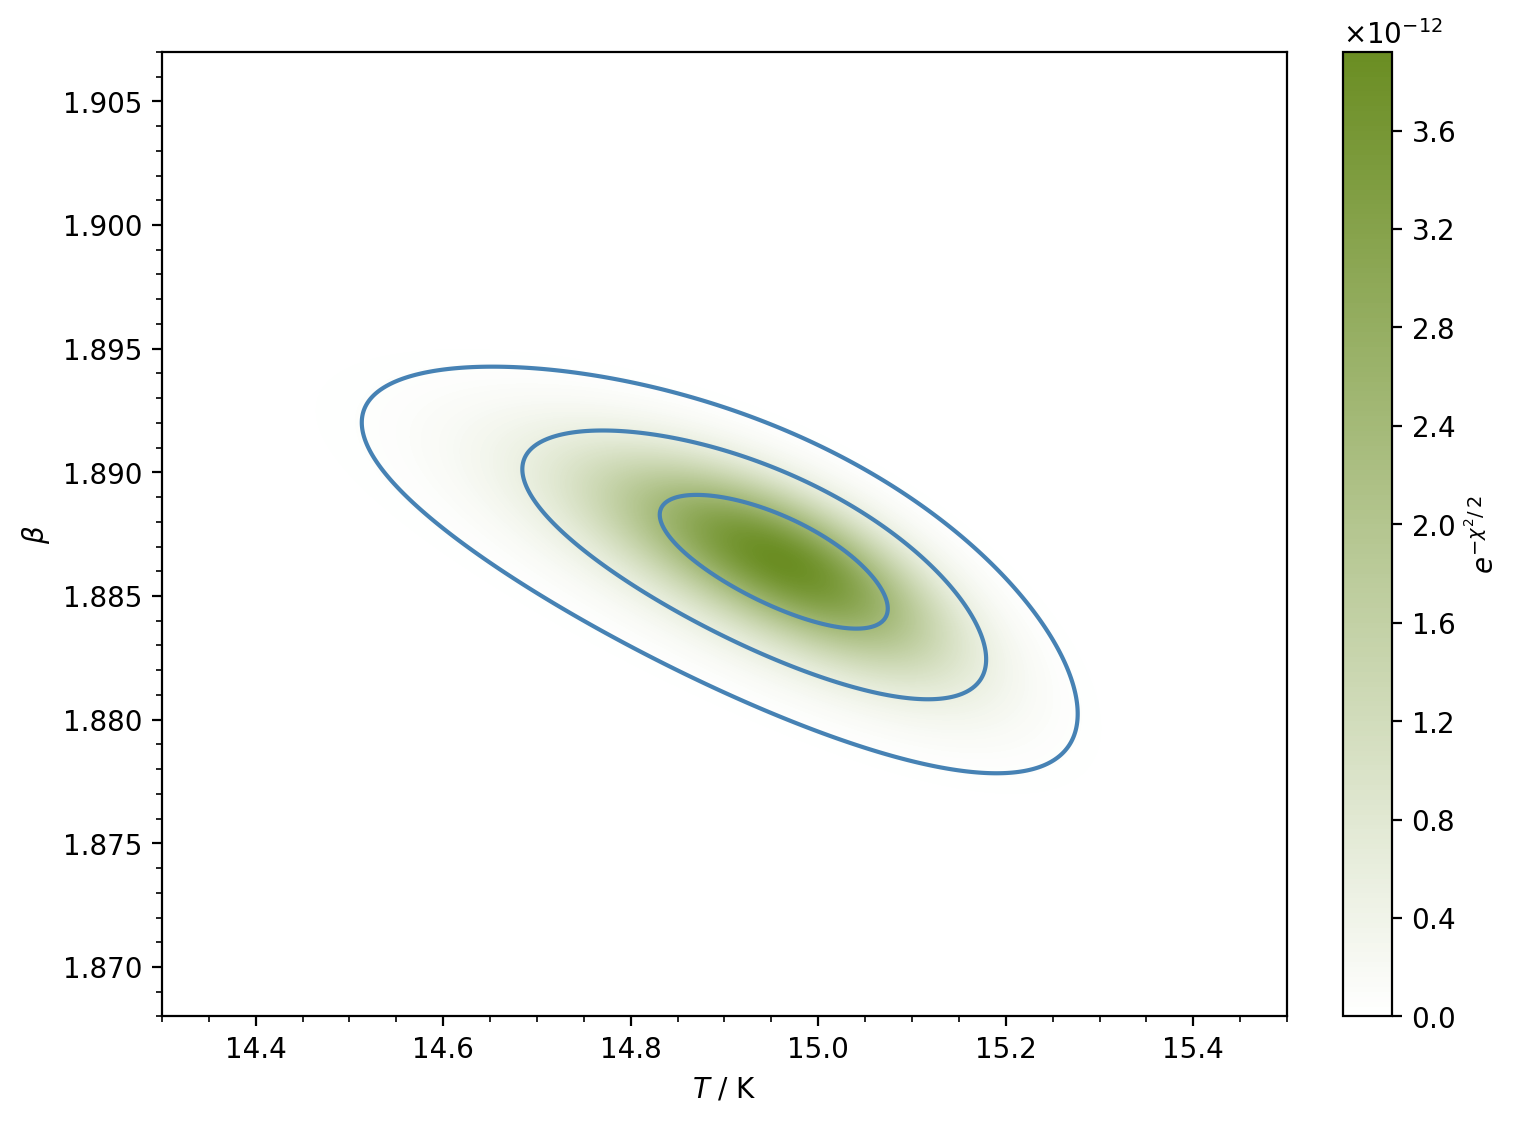

In [12]:
plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contourf(30.0 * X, Y, np.exp(-Z/2), 256, cmap=OliveDrab_r)
cnt.set_edgecolor('face')

ax.contour(30 * X, Y, Z, levels=[minChiSq + 1.0, minChiSq + 4.0, minChiSq + 9.0], colors='steelblue')

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$e^{- \chi^2/\, 2}$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.show()
plt.close()

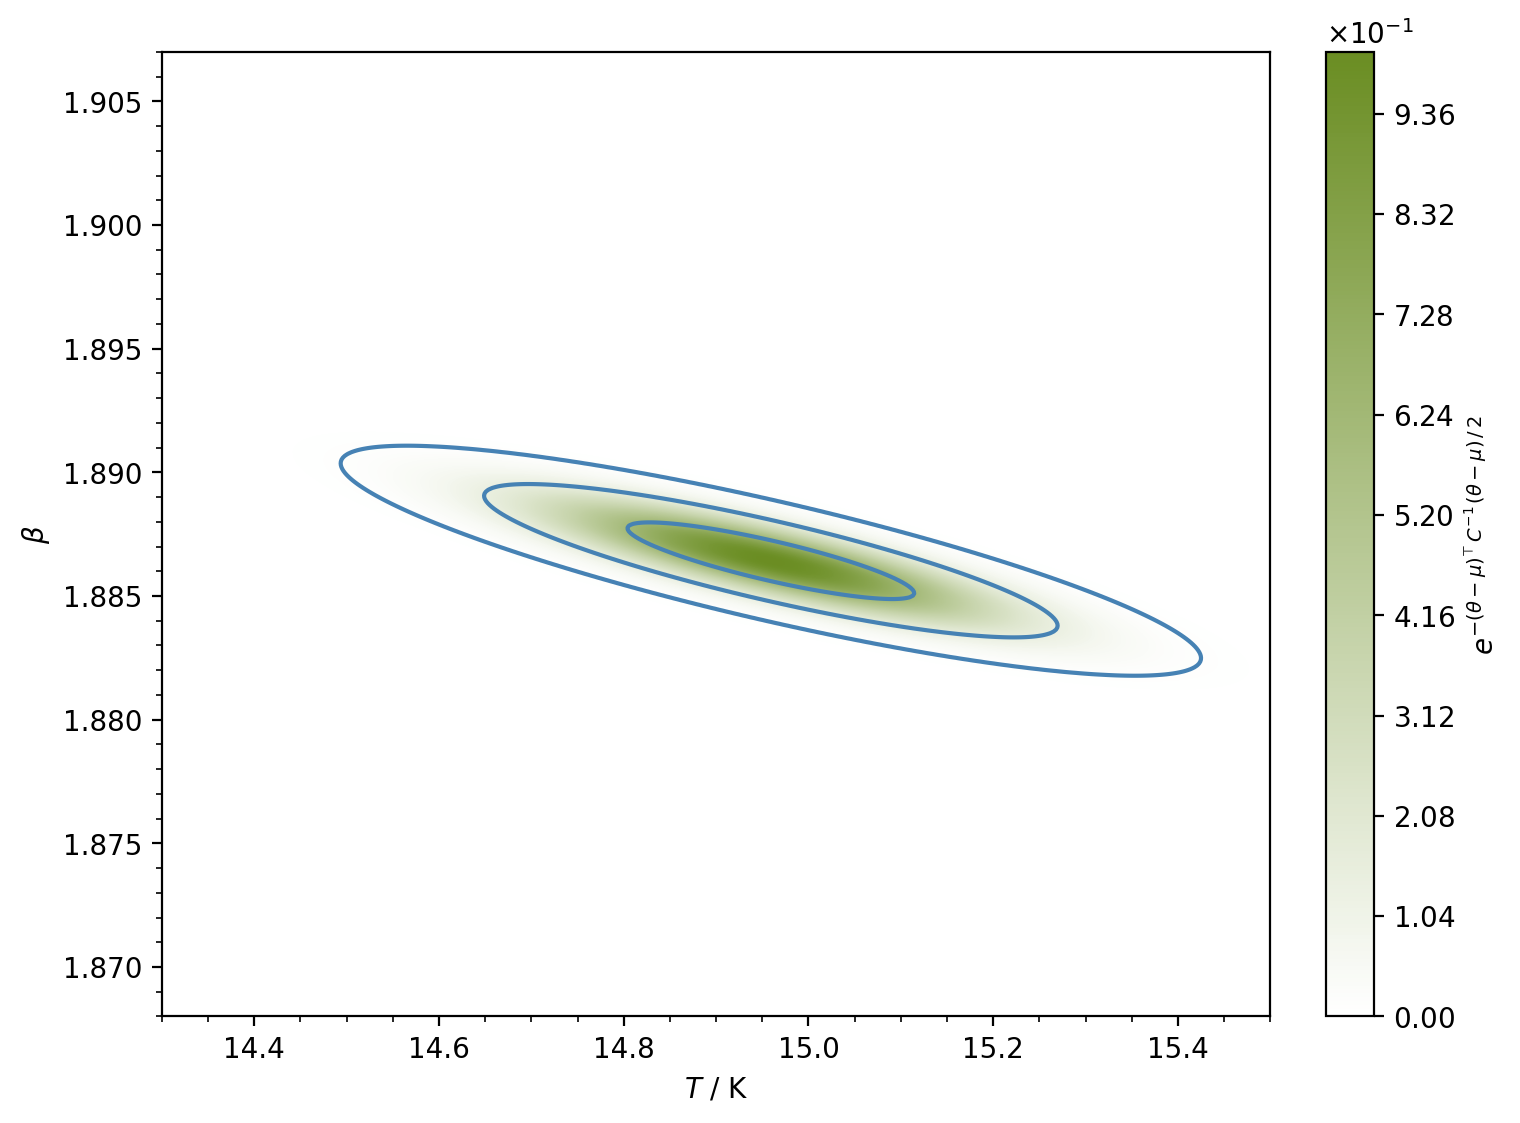

    ┌────────────┬────────────┐
    │ +0.0241028 │ -0.0002037 │
C = ├────────────┼────────────┤
    │ -0.0002037 │ +0.0000024 │
    └────────────┴────────────┘


In [13]:
G = np.array([logLike_TGrad(II, ff, uII, *par) / 30.0, logLike_bGrad(II, ff, uII, *par)])
C = np.linalg.inv(G @ G.T)

cov = C.copy()
cov[0,0] /= 30.0**2
cov[0,1] /= 30.0
cov[1,0] /= 30.0

U = np.zeros(X.shape)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        U[i, j] = gaussian(par, cov, X[i, j], Y[i, j])

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contourf(30.0 * X, Y, U, 256, cmap=OliveDrab_r, zorder=-1)
cnt.set_edgecolor('face')

ax.contour(30 * X, Y, U, levels=[np.exp(-4.5), np.exp(-2.0), np.exp(-0.5)], colors='steelblue')

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$e^{- (\theta - \mu)^{\!\top}C^{-1\,}(\theta - \mu) \,/\, 2}$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.show()
plt.close()

print('    ┌────────────┬────────────┐')
print(f'    │ +{C[0,0]:.7f} │ {C[0,1]:.7f} │')
print('C = ├────────────┼────────────┤')
print(f'    │ {C[1,0]:.7f} │ +{C[1,1]:.7f} │')
print('    └────────────┴────────────┘')

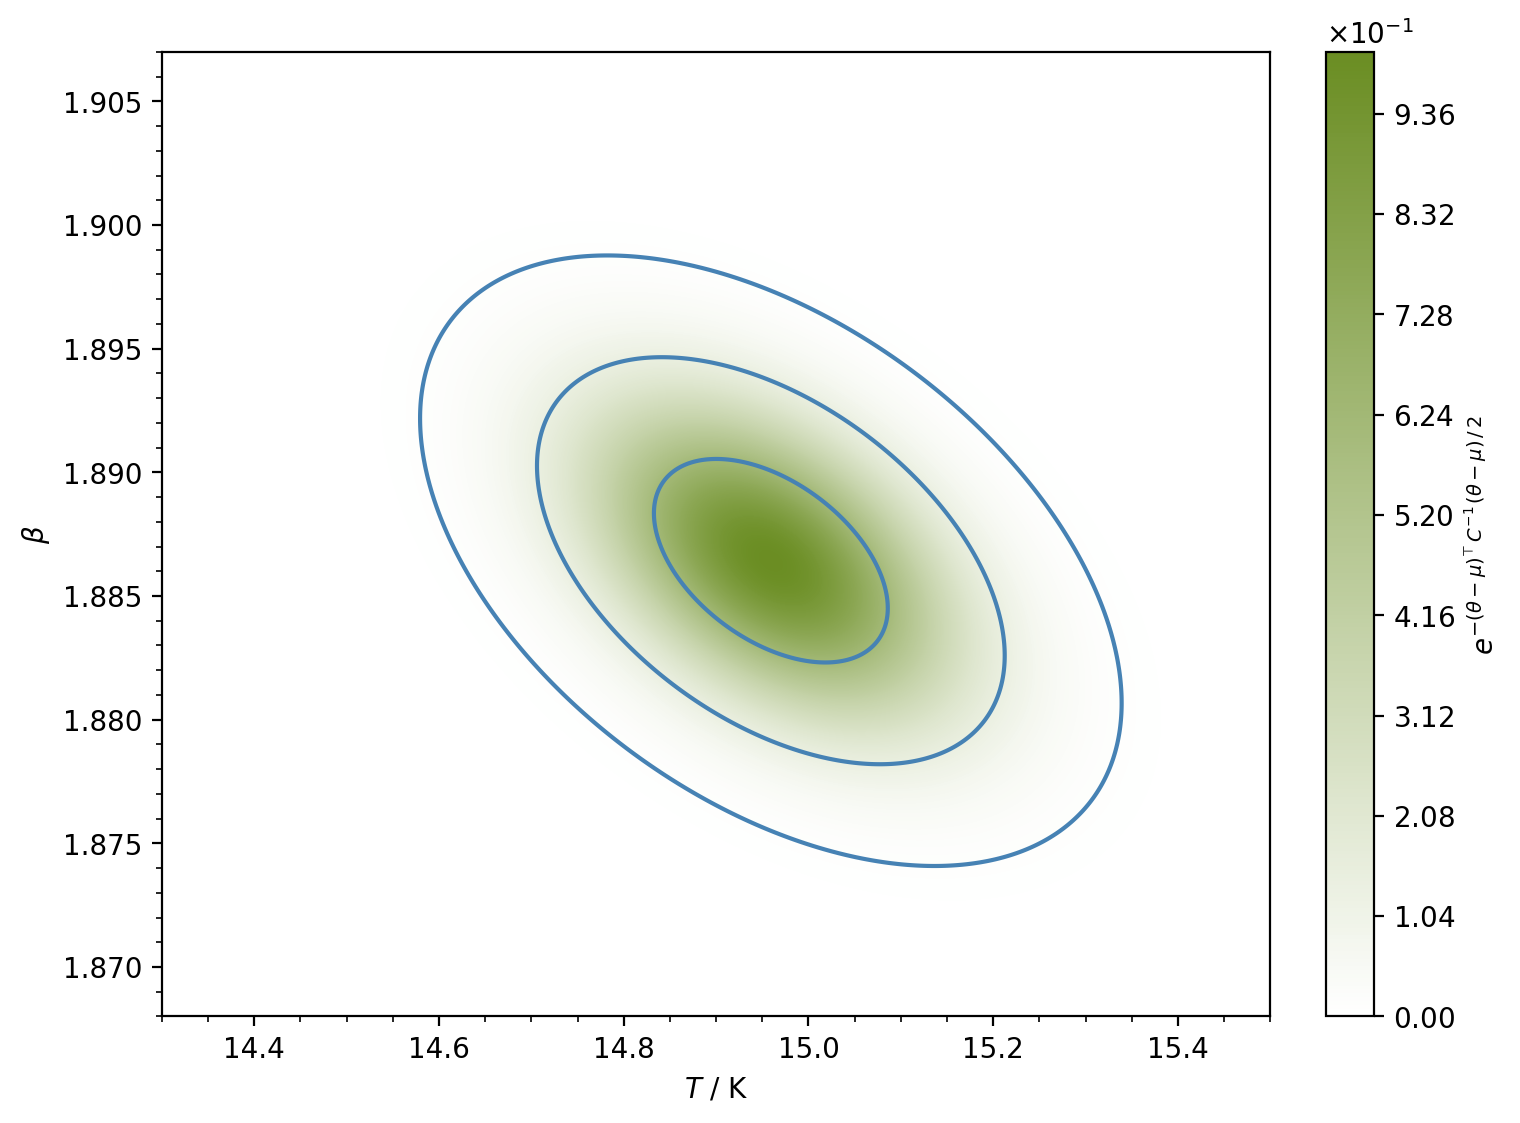

    ┌───────────┬───────────┐
    │ +0.016026 │ -0.000243 │
C = ├───────────┼───────────┤
    │ -0.000243 │ +0.000017 │
    └───────────┴───────────┘


In [14]:
intX, intY = X, Y

intZ = np.exp(- Z / 2)

norm = np.sum(np.sum(intZ * (intY[1, 0] - intY[0, 0]), axis=0) * (intX[0, 1] - intX[0, 0]))

TExpect = np.sum(np.sum(intX[0, :] * intZ * (intY[1, 0] - intY[0, 0]), axis=0) * (intX[0, 1] - intX[0, 0])) / norm
bExpect = np.sum(np.sum(intY[:, 0] * intZ * (intY[1, 0] - intY[0, 0]), axis=0) * (intX[0, 1] - intX[0, 0])) / norm

TVar = np.sum(np.sum((intX[0, :] - TExpect)**2 * intZ * (intY[1, 0] - intY[0, 0]), axis=0) * (intX[0, 1] - intX[0, 0])) / norm
bVar = np.sum(np.sum((intY[:, 0] - bExpect)**2 * intZ * (intY[1, 0] - intY[0, 0]), axis=0) * (intX[0, 1] - intX[0, 0])) / norm

bTCov = np.sum(np.sum((intX - TExpect) * (intY - bExpect) * intZ * (intY[1, 0] - intY[0, 0]), axis=0) * (intX[0, 1] - intX[0, 0])) / norm

C = np.array([[TVar * 30.0**2, bTCov * 30.0], [bTCov * 30.0, bVar]])

cov = np.array([[TVar, bTCov], [bTCov, bVar]])

V = np.zeros(X.shape)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        V[i, j] = gaussian(par, cov, X[i, j], Y[i, j])

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contourf(30.0 * X, Y, V, 256, cmap=OliveDrab_r, zorder=-1)
cnt.set_edgecolor('face')

ax.contour(30 * X, Y, V, levels=[np.exp(-4.5), np.exp(-2.0), np.exp(-0.5)], colors='steelblue')

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$e^{- (\theta - \mu)^{\!\top}C^{-1\,}(\theta - \mu) \,/\, 2}$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.show()
plt.close()

print('    ┌───────────┬───────────┐')
print(f'    │ +{C[0,0]:.6f} │ {C[0,1]:.6f} │')
print('C = ├───────────┼───────────┤')
print(f'    │ {C[1,0]:.6f} │ +{C[1,1]:.6f} │')
print('    └───────────┴───────────┘')

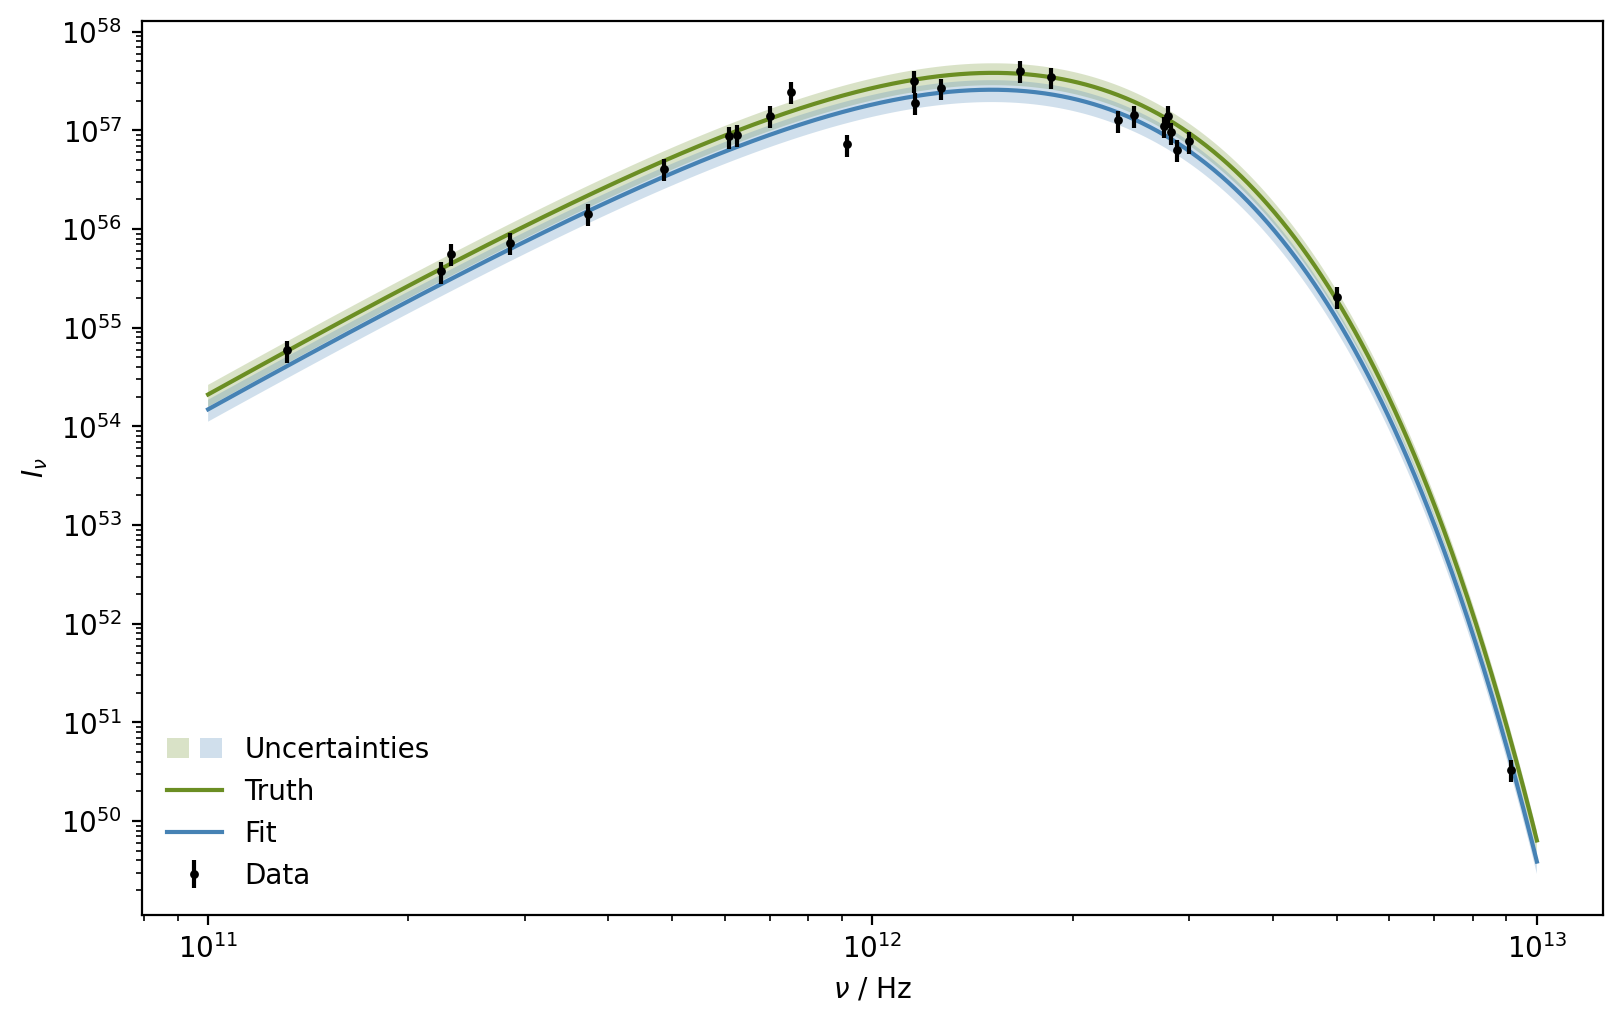

In [15]:
# Plot: Fit versus Truth

z = modBB(x, *par)

p1 = plt.fill_between(x, (1 + u) * y, (1 - u) * y, alpha=0.25)
p2, = plt.plot(x, y)
p3 = plt.fill_between(x, (1 + u) * z, (1 - u) * z, alpha=0.25)
p4, = plt.plot(x, z)
p5 = plt.errorbar(ff, II, yerr=uII, fmt='k.', ms=4.32)

plt.xlabel(r'$\nu$ / Hz')
plt.ylabel(r'$I_\nu$')

plt.xscale('log')
plt.yscale('log')

plt.legend([(p1, p3), p2, p4, p5], ['Uncertainties', 'Truth', 'Fit', 'Data'],
           handler_map={tuple: HandlerTuple(ndivide=None)}, loc='lower left')

plt.show()
plt.close()

In [196]:
def metroMCMC(n, T, b, I, f, s, h = 0.001):
    theta = np.array([[T / 30.0, b]])
    k = 0
    l = 0
    while n > l + 1:
        th = np.random.normal(theta[l, :], [h, h])
        r = np.exp((chiSq(I, f, s, *theta[l, :]) - chiSq(I, f, s, *th)) / 2)
        if r >= 1.0:
            theta = np.append(theta, [th], axis=0)
            l += 1
        else:
            p = np.random.uniform(0.0, 1.0)
            if r >= p:
                theta = np.append(theta, [th], axis=0)
                l += 1
        k += 1
    return [theta, k]

chain1, k1 = metroMCMC(250000, 15.40, 1.905, II, ff, uII, h = 0.0005)

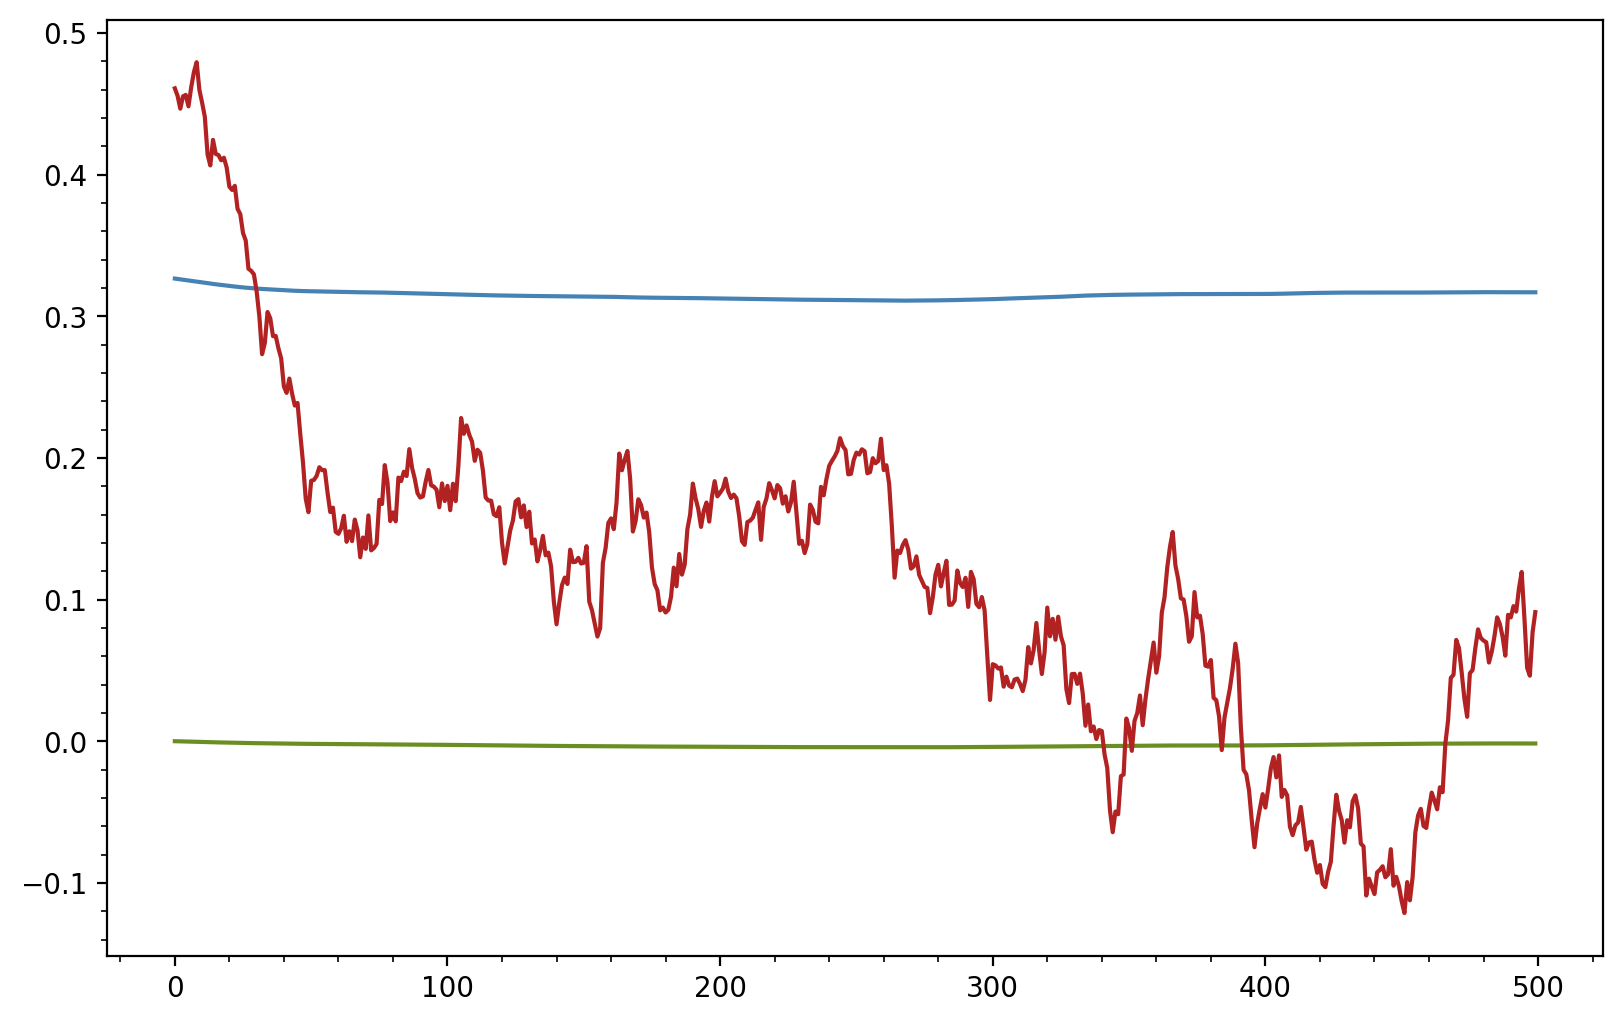

In [197]:
TSamp = 30.0 * chain1[:, 0]
bSamp = chain1[:, 1]

TMean = np.mean(TSamp)
bMean = np.mean(bSamp)

TMean, bMean

def rollMean(arr, n):
    ret = np.zeros(len(arr) - n)
    m = 0
    for el in ret:
        ret[m] = np.mean(arr[m:n + m])
        m += 1
    return ret

def rollUnc(arr, n):
    ret = np.zeros(len(arr) - n)
    m = 0
    for el in ret:
        ret[m] = np.std(arr[m:n + m])
        m += 1
    return ret

#plt.plot(TSamp[:5000] - TMean)


plt.plot(rollMean(TSamp - TMean, 10000)[:500])
plt.plot(3 * rollUnc(TSamp - TMean, 10000)[:500])
plt.plot(TSamp[:500] - TMean)

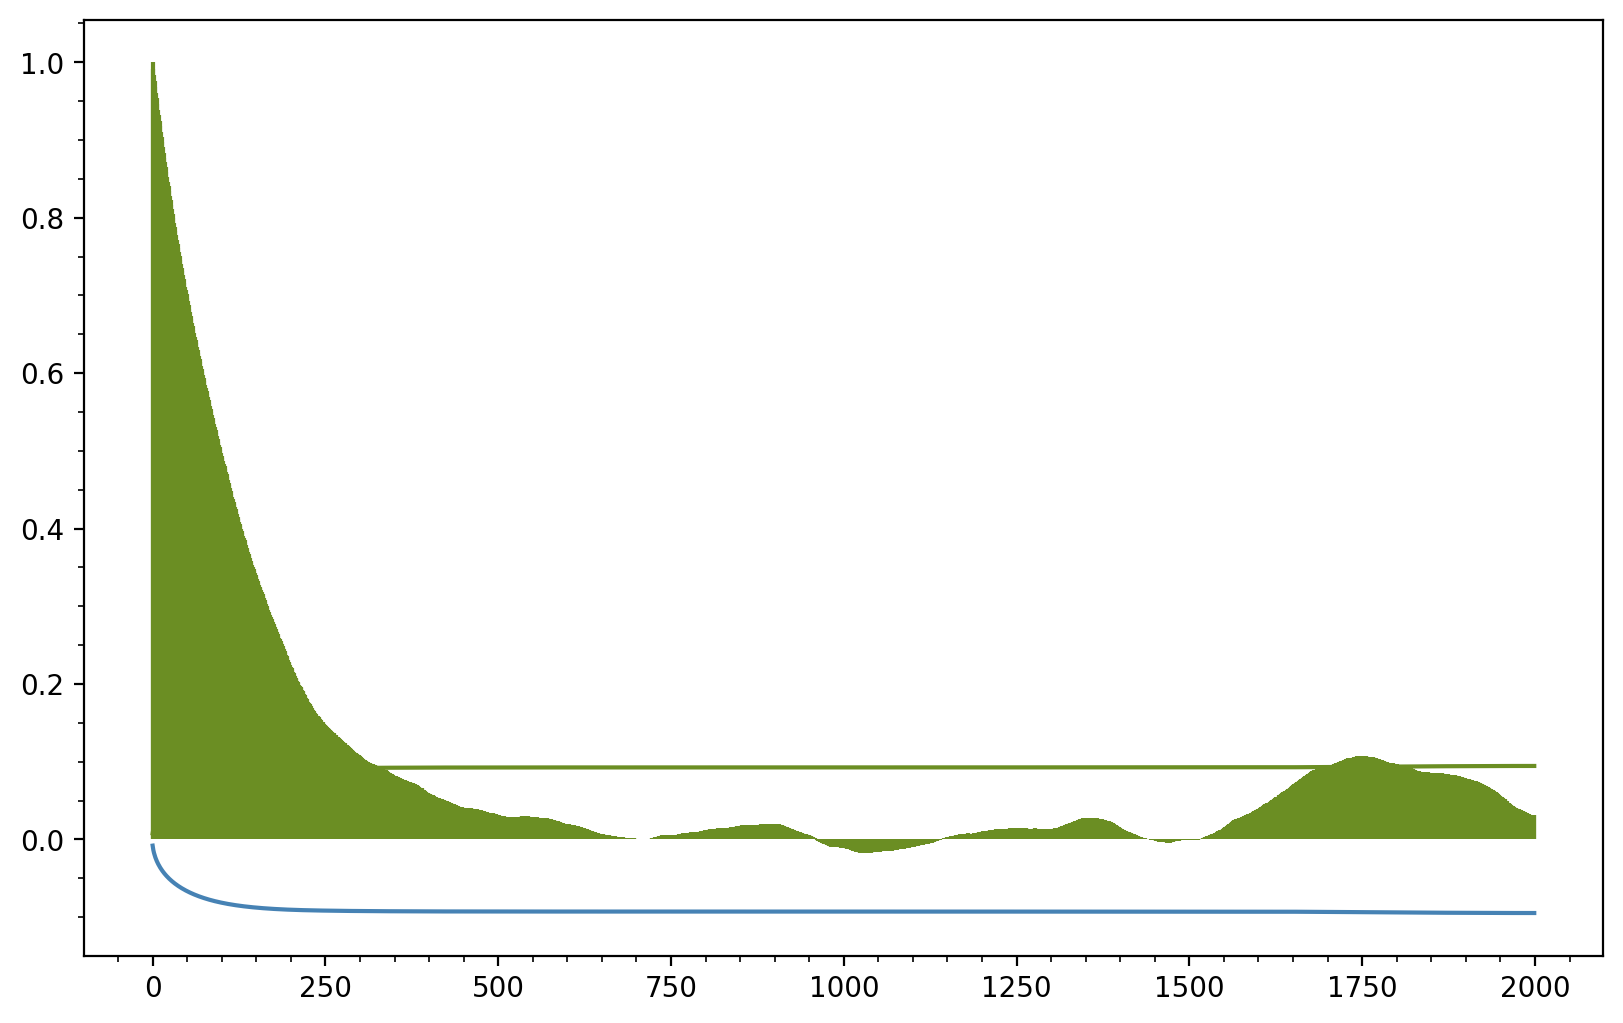

In [200]:
def autoCorrCoeff(arr, n, m):
    if n + m < len(arr):
        ret = np.zeros(n)
        err = np.zeros(n)
        t = np.array([0])
        for el in ret:
            now = arr[t[-1]:t[-1] + m]
            lag = arr[:m]
            #ret[t[-1]] = np.cov([now, lag]) / (np.std(now) * np.std(lag))
            ret[t[-1]] = np.mean((now - np.mean(now)) * (lag - np.mean(lag))) / (np.std(now) * np.std(lag))
            #err[t[-1]] = np.std((now - np.mean(now)) * (lag - np.mean(lag))) / (np.std(now) * np.std(lag))
            err[t[-1]] = np.sqrt((2 * np.sum(ret**2) - 1) / m)
            t = np.append(t, t[-1] + 1)
        return [ret, err, t[:-1]]

TAcorr, TAerr, ttt = autoCorrCoeff(TSamp[50000:], 2000, 100000)

plt.vlines(ttt, 0, TAcorr)
plt.plot(ttt, 2.5 * TAerr)
plt.plot(ttt, -2.5 * TAerr)